# Testing file 1

## Stellar light curves from the Keplar Mission


In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt


# --- AUTOMATIC FIGURE DIRECTORY HANDLING ---
os.makedirs("figures", exist_ok=True)

# --- GLOBAL PLOTTING STYLE UPGRADE ---
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5,
    'scatter.marker': 'o'
})
print("Publication plotting style and /figures/ directory initialized.")

# Load data (handle NA safely) and save memory using float32
flux1 = np.genfromtxt("datasets/Kepler1.dat", dtype=np.float32, missing_values="NA", filling_values=np.nan)
flux2 = np.genfromtxt("datasets/Kepler2.dat", dtype=np.float32, missing_values="NA", filling_values=np.nan)

# Count missing values
n_missing_flux1 = np.isnan(flux1).sum()
n_missing_flux2 = np.isnan(flux2).sum()
n_total_flux1 = len(flux1)
n_total_flux2 = len(flux2)
print(f"Kepler1: {n_missing_flux1}/{n_total_flux1} ({100 * n_missing_flux1 / n_total_flux1:.2f}% missing)")
print(f"kepler2: {n_missing_flux2}/{n_total_flux2} ({100 * n_missing_flux2 / n_total_flux2:.2f}% missing)")

Publication plotting style and /figures/ directory initialized.
Kepler1: 11337/71427 (15.87% missing)
kepler2: 20598/71427 (28.84% missing)


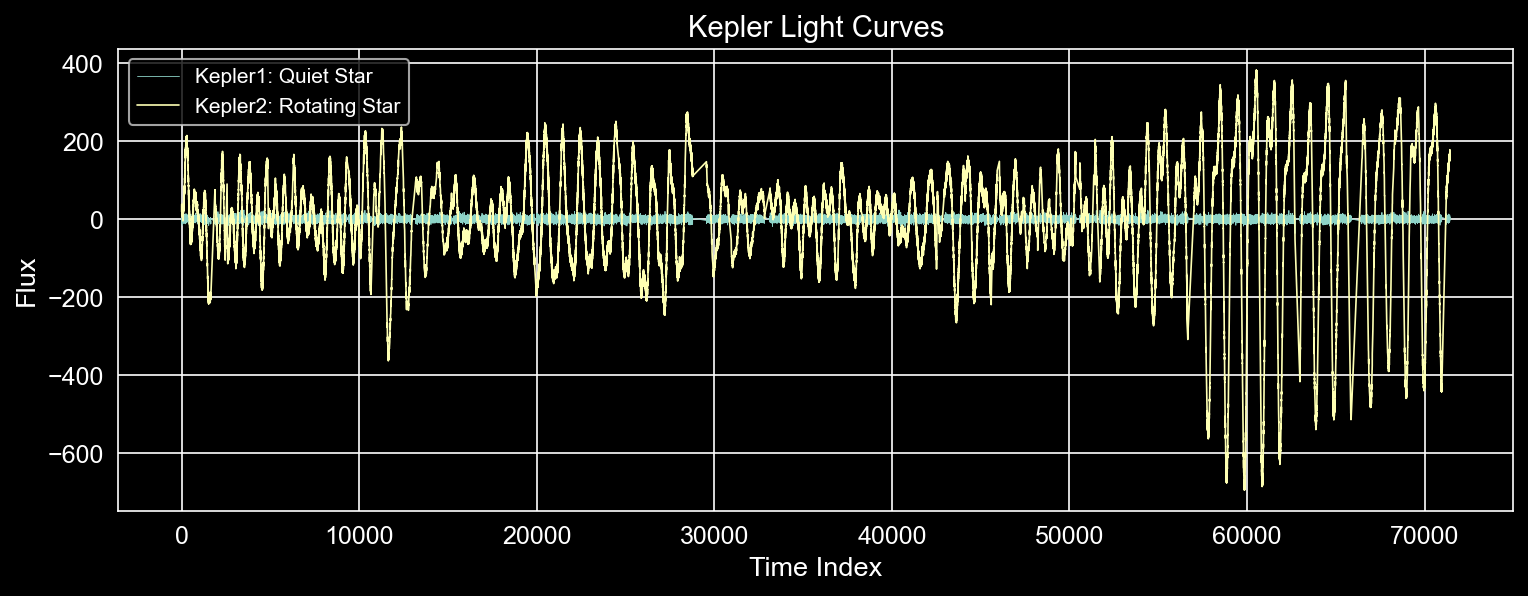

In [3]:
# Masked plots to ignore NaNs
t1 = np.arange(len(flux1))
t2 = np.arange(len(flux2))

plt.figure(figsize=(12, 4))
plt.plot(t1[~np.isnan(flux1)], flux1[~np.isnan(flux1)], lw=0.4, label='Kepler1: Quiet Star')
plt.plot(t2[~np.isnan(flux2)], flux2[~np.isnan(flux2)], lw=0.8, label='Kepler2: Rotating Star')
plt.xlabel("Time Index")
plt.ylabel("Flux")
plt.legend()
plt.title("Kepler Light Curves")
plt.grid(True)
plt.show()

In [4]:
from scipy.interpolate import interp1d

# Only use valid indices
valid1 = ~np.isnan(flux1)
interp_func1 = interp1d(t1[valid1], flux1[valid1], kind='linear', fill_value="extrapolate")
flux1_interp = interp_func1(t1)

valid2 = ~np.isnan(flux2)
interp_func2 = interp1d(t2[valid2], flux2[valid2], kind = 'linear', fill_value = 'extrapolate')
flux2_interp = interp_func2(t2)

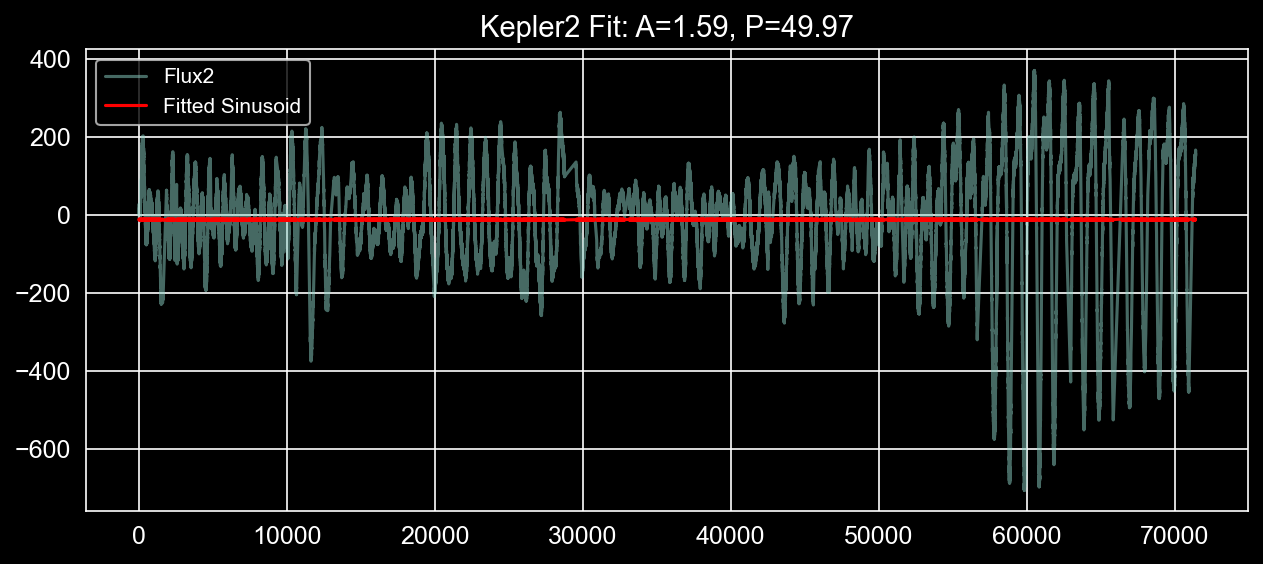

In [5]:
from scipy.optimize import curve_fit

def sinusoid(t, A, P, phi, offset):
    return A * np.sin(2 * np.pi * t / P + phi) + offset

# Use only finite values
finite = ~np.isnan(flux2)
t_fit = t2[finite]
f_fit = flux2[finite] - np.nanmedian(flux2)

# Initial guesses: A=10, P=50, phi=0, offset=0
popt, _ = curve_fit(sinusoid, t_fit, f_fit, p0=[10, 50, 0, 0])
A, P, phi, offset = popt

# Reconstruct fitted signal
fitted = sinusoid(t_fit, *popt)

plt.figure(figsize=(10, 4))
plt.plot(t_fit, f_fit, label='Flux2', alpha=0.5)
plt.plot(t_fit, fitted, label='Fitted Sinusoid', color='r')
plt.legend()
plt.title(f"Kepler2 Fit: A={A:.2f}, P={P:.2f}")
plt.grid(True)
plt.show()

## Using Gaussian Processes to simulate probable noise

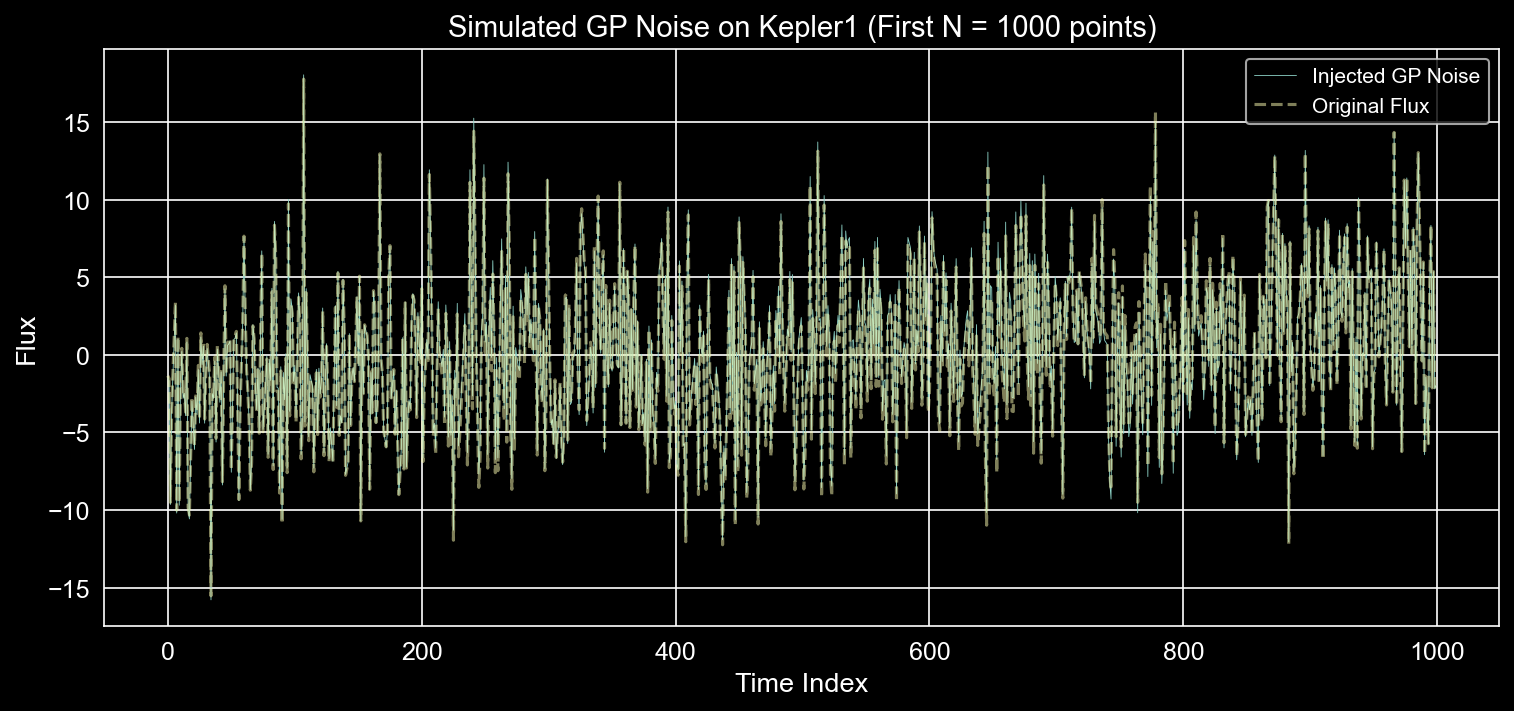

In [6]:
np.random.seed(442)

def man_ExpSquaredKernel(t1, t2=None, A=1.0, l=1.0):
    if t2 is None:
        t2 = t1
    T2, T1 = np.meshgrid(t2, t1)
    return A ** 2 * np.exp(-0.5 * (T1-T2)**2 / l**2)

N = 1000
t1_sub = t1[:N]
flux1_sub = flux1_interp[:N]

cov1_sub = man_ExpSquaredKernel(t1_sub, A = 0.5, l = 50.0)
gp_noise_sub1 = np.random.multivariate_normal(mean=np.zeros(N), cov=cov1_sub)

# Add GP noise
flux_gp_injected1 = flux1_sub + gp_noise_sub1

plt.figure(figsize=(12, 5))
plt.plot(t1_sub, flux_gp_injected1, label='Injected GP Noise', lw = 0.4)
plt.plot(t1_sub, flux1_sub, '--', label='Original Flux', alpha=0.5)
plt.xlabel("Time Index")
plt.ylabel("Flux")
plt.legend()
plt.title("Simulated GP Noise on Kepler1 (First N = 1000 points)")
plt.grid(True)
plt.show()

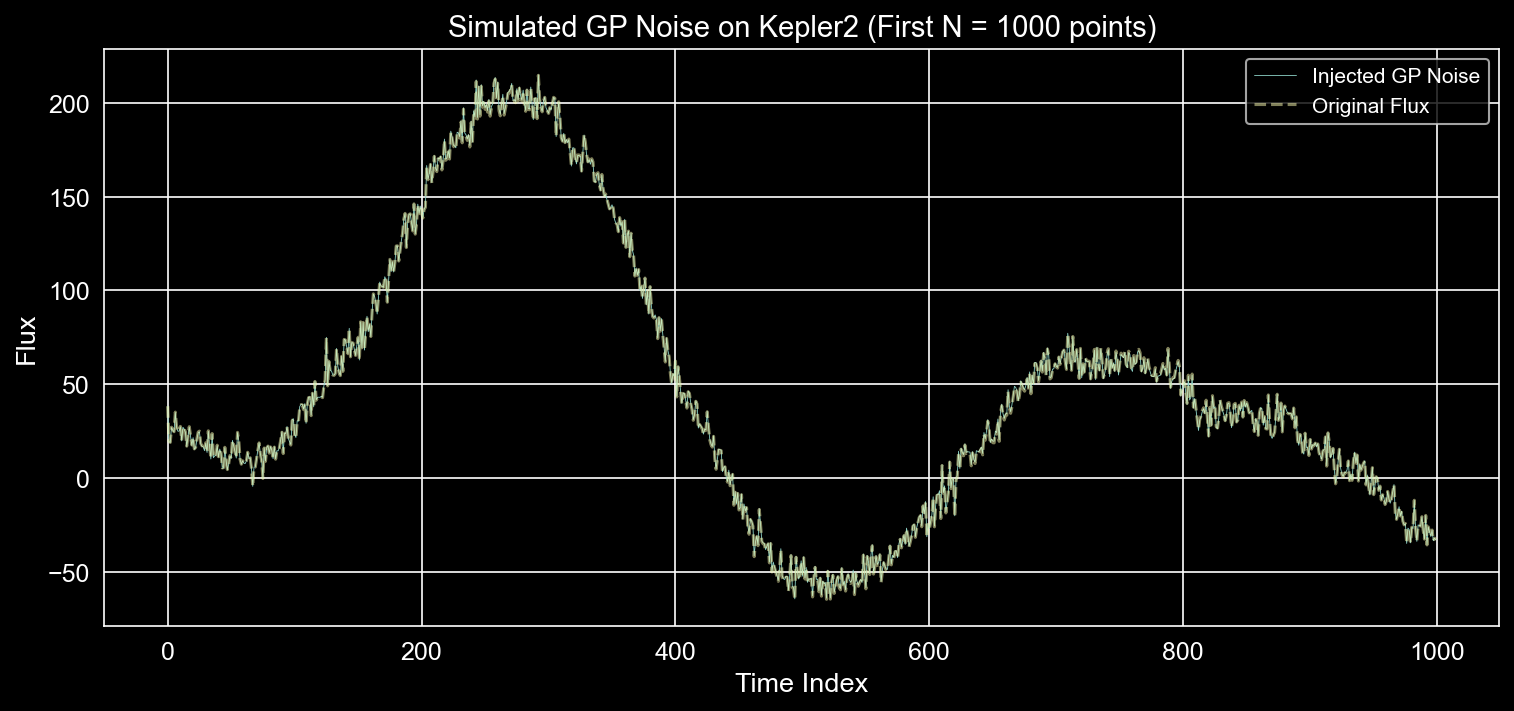

In [7]:
np.random.seed(442)

N = 1000
t2_sub = t2[:N]
flux2_sub = flux2_interp[:N]

cov2_sub = man_ExpSquaredKernel(t2_sub, A = 0.5, l = 50.0)
gp_noise_sub2 = np.random.multivariate_normal(mean=np.zeros(N), cov=cov2_sub)

# Add GP noise
flux_gp_injected2 = flux2_sub + gp_noise_sub2

plt.figure(figsize=(12, 5))
plt.plot(t2_sub, flux_gp_injected2, label='Injected GP Noise', lw = 0.4)
plt.plot(t2_sub, flux2_sub, '--', label='Original Flux', alpha=0.5)
plt.xlabel("Time Index")
plt.ylabel("Flux")
plt.legend()
plt.title("Simulated GP Noise on Kepler2 (First N = 1000 points)")
plt.grid(True)
plt.show()

## Modeling around Kepler datas using GPR

### Kepler 1 imputation

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.interpolate import interp1d
import IPython.display as display

import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import pmdarima as pm

# Step 1: Load flux data (Note: ensure path matches your environment)
flux1 = np.genfromtxt("datasets/Kepler1.dat", dtype=np.float32, missing_values="NA", filling_values=np.nan)

# Extract a continuous chunk of Kepler 1 data for order selection
# (using forward fill to temporarily handle NaNs for auto_arima)
flux1_ffill = pd.Series(flux1).fillna(method='ffill').dropna().values
chunk_size = min(2000, len(flux1_ffill)) # Use a subset for tractability
train_chunk = flux1_ffill[:chunk_size]

print("Running auto_arima to select optimal (p,d,q)...")
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    auto_model = pm.auto_arima(
        train_chunk,
        start_p=0, start_q=0,
        max_p=5, max_q=5,
        d=0,
        seasonal=False,
        trace=True,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )
best_arima_order = auto_model.order
print(f"--> Selected ARIMA order for MC Benchmark: {best_arima_order}")

# Step 2: Create time index
t1 = np.arange(len(flux1))

# Step 3: Get observed (non-NaN) values ONLY
mask = ~np.isnan(flux1)
t1_valid = t1[mask]
y1_valid = flux1[mask]

# Step 3.5: Subsample the flux data before split to manage O(N^3) memory constraints
subset = 100
t1_sub = t1_valid[::subset]
y1_sub = y1_valid[::subset]
print(len(t1_sub))

/var/folders/rr/dyz2s1qs445_d0g9kdcbwl_w0000gn/T/ipykernel_68670/702885688.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  flux1_ffill = pd.Series(flux1).fillna(method='ffill').dropna().values


Running auto_arima to select optimal (p,d,q)...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=12155.383, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=11951.350, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=12002.883, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=11902.277, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=11865.592, Time=0.02 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=11840.691, Time=0.03 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=11827.756, Time=0.33 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=11718.218, Time=0.63 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=11716.311, Time=0.48 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=11714.316, Time=0.11 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=11712.372, Time=0.16 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=11725.409, Time=0.04 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=11714.317, Time=0.31 sec
 ARIMA(1,0,2)(0,0,0)[0]             : 

In [21]:

# Step 3.6: Randomized Train-Test Split (80% Train, 20% Test)

# --- 1. Setup Monte Carlo Cross-Validation ---
n_repetitions = 20
seeds = range(n_repetitions)

# Storage for GP metrics
gp_rmse_list, gp_mae_list, gp_r2_list = [], [], []
gp_1sigma_list, gp_2sigma_list, gp_std_list = [], [], []

# Storage for Baseline metrics
lin_rmse_list, lin_mae_list, lin_r2_list = [], [], []
arima_rmse_list, arima_mae_list, arima_r2_list = [], [], []

print(f"Running Monte Carlo Cross-Validation across {n_repetitions} seeds...")

kernel1 = 1.0 * RBF(length_scale=100.0) + WhiteKernel(noise_level=1.0)

for seed in seeds:

    # statsmodels handles NaNs in the endogenous variable out-of-the-box
    # using the Kalman filter, which is perfect for our masked indices.
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        warnings.simplefilter('ignore', UserWarning)

        # Randomized Split
        t1_train, t1_test, y1_train, y1_test = train_test_split(
            t1_sub, y1_sub, test_size=0.2, random_state=seed
        )

        # Sort arrays for clean interpolation
        sort_train = np.argsort(t1_train)
        t1_train, y1_train = t1_train[sort_train], y1_train[sort_train]
        sort_test = np.argsort(t1_test)
        t1_test, y1_test = t1_test[sort_test], y1_test[sort_test]

        X1_train, X1_test = t1_train.reshape(-1, 1), t1_test.reshape(-1, 1)

        # --- Fit & Evaluate GP ---
        gpr1 = GaussianProcessRegressor(kernel=kernel1, alpha=1e-2, normalize_y=True, random_state=seed)
        gpr1.fit(X1_train, y1_train)
        y1_pred, y1_std = gpr1.predict(X1_test, return_std=True)

        gp_rmse_list.append(np.sqrt(mean_squared_error(y1_test, y1_pred)))
        gp_mae_list.append(mean_absolute_error(y1_test, y1_pred))
        gp_r2_list.append(r2_score(y1_test, y1_pred))
        gp_std_list.append(np.mean(y1_std))

        # Uncertainty Coverage
        gp_1sigma_list.append(np.mean((y1_test >= y1_pred - y1_std) & (y1_test <= y1_pred + y1_std)))
        gp_2sigma_list.append(np.mean((y1_test >= y1_pred - 2*y1_std) & (y1_test <= y1_pred + 2*y1_std)))

        # --- Fit & Evaluate Baselines ---
        # Linear
        lin_interp = interp1d(t1_train, y1_train, kind='linear', fill_value='extrapolate')
        y_pred_lin = lin_interp(t1_test)
        lin_rmse_list.append(np.sqrt(mean_squared_error(y1_test, y_pred_lin)))
        lin_mae_list.append(mean_absolute_error(y1_test, y_pred_lin))
        lin_r2_list.append(r2_score(y1_test, y_pred_lin))

        # ARIMA
        # 1. Create a sequential array mimicking the full light curve
        y1_arima_input = y1_sub.copy().astype(float)
        # 2. Hide the test data by injecting NaNs where t1_sub matches t1_test
        test_mask_arima = np.isin(t1_sub, t1_test)
        y1_arima_input[test_mask_arima] = np.nan
        # 3. Fit ARIMA (statsmodels uses the Kalman filter to step over NaNs)
        arima_model = ARIMA(y1_arima_input, order=best_arima_order)
        arima_res = arima_model.fit()
        # 4. Predict the entire sequence
        arima_preds_all = arima_res.predict(start=0, end=len(y1_arima_input)-1)
        # 5. Extract ONLY the test predictions and map them to the sorted t1_test array
        pred_dict = dict(zip(t1_sub[test_mask_arima], arima_preds_all[test_mask_arima]))
        y_pred_arima = np.array([pred_dict[t] for t in t1_test])
        # 6. Calculate Metrics
        arima_rmse_list.append(np.sqrt(mean_squared_error(y1_test, y_pred_arima)))
        arima_mae_list.append(mean_absolute_error(y1_test, y_pred_arima))
        arima_r2_list.append(r2_score(y1_test, y_pred_arima))

print("Monte Carlo evaluation complete.")

/var/folders/rr/dyz2s1qs445_d0g9kdcbwl_w0000gn/T/ipykernel_68670/2593393355.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  flux1_ffill = pd.Series(flux1).fillna(method='ffill').dropna().values


Running auto_arima to select optimal (p,d,q)...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=12155.383, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=11951.350, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=12002.883, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=11902.277, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=11865.592, Time=0.01 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=11840.691, Time=0.03 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=11827.756, Time=0.31 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=11718.218, Time=0.89 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=11716.311, Time=0.45 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=11714.316, Time=0.22 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=11712.372, Time=0.10 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=11725.409, Time=0.04 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=11714.317, Time=0.32 sec
 ARIMA(1,0,2)(0,0,0)[0]             : 

In [22]:
# --- 1. Compute Aggregates ---
benchmark_data = {
    "Method": ["Linear Interpolation", "ARIMA", "Gaussian Process"],
    "RMSE Mean": [np.mean(lin_rmse_list), np.mean(arima_rmse_list), np.mean(gp_rmse_list)],
    "RMSE Std": [np.std(lin_rmse_list), np.std(arima_rmse_list), np.std(gp_rmse_list)],
    "MAE Mean": [np.mean(lin_mae_list), np.mean(arima_mae_list), np.mean(gp_mae_list)],
    "MAE Std": [np.std(lin_mae_list), np.std(arima_mae_list), np.std(gp_mae_list)],
    "R² Mean": [np.mean(lin_r2_list), np.mean(arima_r2_list), np.mean(gp_r2_list)],
    "R² Std": [np.std(lin_r2_list), np.std(arima_r2_list), np.std(gp_r2_list)]
}

benchmark_df = pd.DataFrame(benchmark_data)

print("--- Kepler 1 Benchmark Results (20 Seeds) ---")
display.display(benchmark_df.round(4))

# --- 2. Uncertainty Calibration Summary ---
print("\n--- GP Uncertainty Calibration Summary ---")
print(f"Average 1σ Coverage: {np.mean(gp_1sigma_list)*100:.2f}% ± {np.std(gp_1sigma_list)*100:.2f}% (Ideal: ~68%)")
print(f"Average 2σ Coverage: {np.mean(gp_2sigma_list)*100:.2f}% ± {np.std(gp_2sigma_list)*100:.2f}% (Ideal: ~95%)")

# --- 3. Best/Worst Case Analysis ---
best_seed_idx = np.argmin(gp_rmse_list)
worst_seed_idx = np.argmax(gp_rmse_list)
print("\n--- Sensitivity to Train-Test Split ---")
print(f"Best GP RMSE:  {gp_rmse_list[best_seed_idx]:.4f} (Seed {seeds[best_seed_idx]})")
print(f"Worst GP RMSE: {gp_rmse_list[worst_seed_idx]:.4f} (Seed {seeds[worst_seed_idx]})")

--- Kepler 1 Benchmark Results (20 Seeds) ---


,Method,RMSE Mean,RMSE Std,MAE Mean,MAE Std,R² Mean,R² Std
0,Linear Interpolation,6.2827,0.3437,5.1008,0.3127,-0.5733,0.1151
1,ARIMA,5.0446,0.2521,4.1107,0.2142,-0.0123,0.0192
2,Gaussian Process,5.0477,0.2525,4.1156,0.2176,-0.0136,0.0182



--- GP Uncertainty Calibration Summary ---
Average 1σ Coverage: 65.12% ± 4.24% (Ideal: ~68%)
Average 2σ Coverage: 96.07% ± 1.63% (Ideal: ~95%)

--- Sensitivity to Train-Test Split ---
Best GP RMSE:  4.6718 (Seed 11)
Worst GP RMSE: 5.5869 (Seed 7)


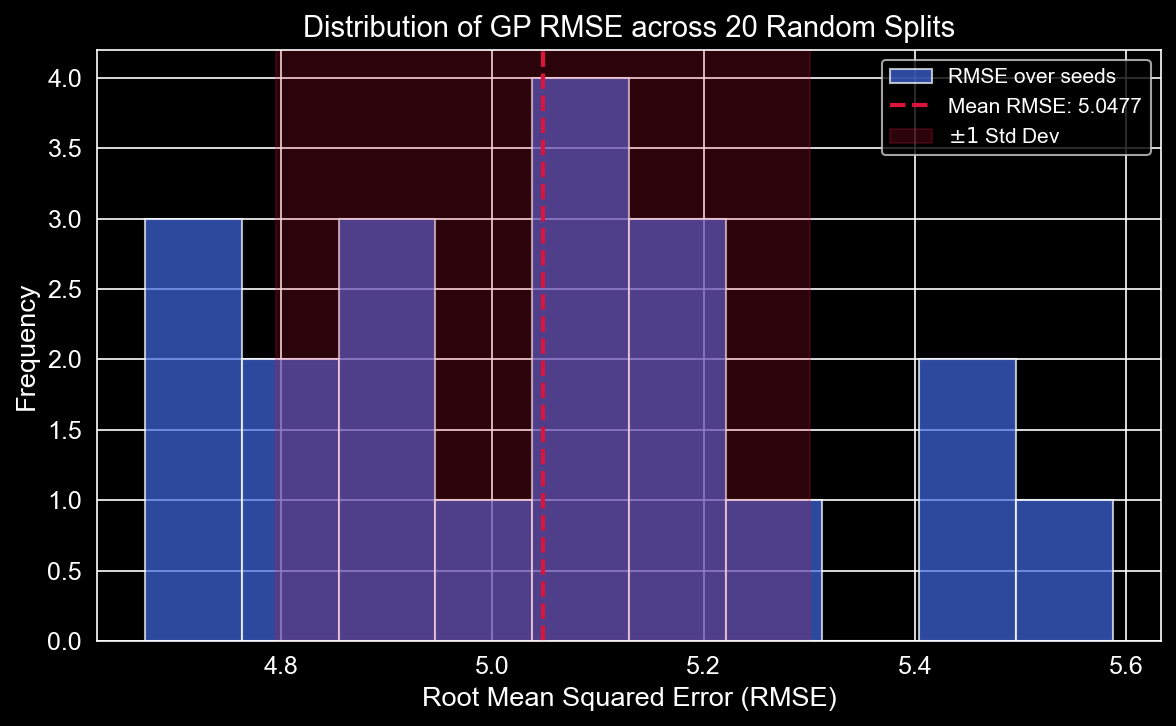

In [34]:
# --- Plot RMSE Distribution ---
plt.figure(figsize=(8, 5))
mean_rmse = np.mean(gp_rmse_list)
std_rmse = np.std(gp_rmse_list)

plt.hist(gp_rmse_list, bins=10, color='royalblue', edgecolor='white', alpha=0.7, label='RMSE over seeds')
plt.axvline(mean_rmse, color='crimson', linestyle='dashed', linewidth=2, label=f'Mean RMSE: {mean_rmse:.4f}')
plt.axvspan(mean_rmse - std_rmse, mean_rmse + std_rmse, color='crimson', alpha=0.2, label=r'$\pm 1$ Std Dev')

plt.title(f"Distribution of GP RMSE across {n_repetitions} Random Splits", fontsize=14)
plt.xlabel("Root Mean Squared Error (RMSE)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("figures/kepler1_rmse_distribution.png", bbox_inches='tight')
plt.show()

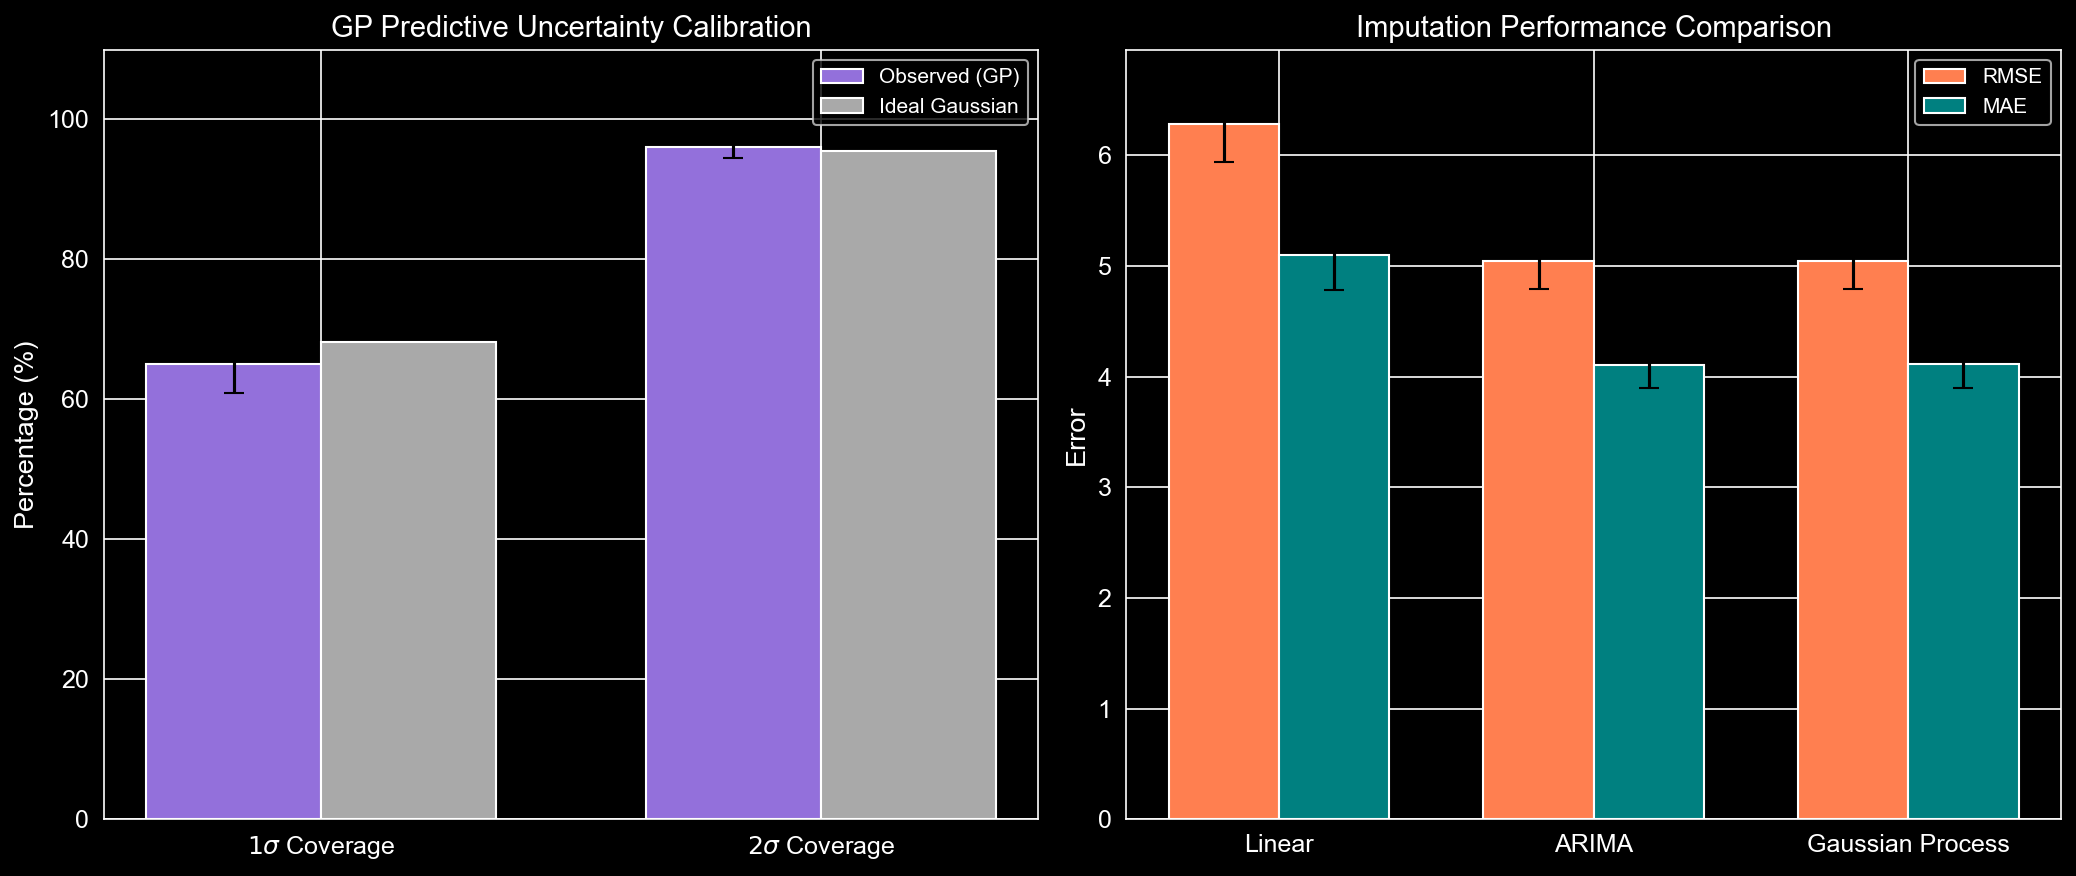

In [23]:
# --- Uncertainty Calibration Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Calibration
categories = [r'$1\sigma$ Coverage', r'$2\sigma$ Coverage']
observed_means = [np.mean(gp_1sigma_list) * 100, np.mean(gp_2sigma_list) * 100]
observed_stds = [np.std(gp_1sigma_list) * 100, np.std(gp_2sigma_list) * 100]
ideal_values = [68.27, 95.45]

x = np.arange(len(categories))
width = 0.35

axes[0].bar(x - width/2, observed_means, width, yerr=observed_stds, capsize=5, color='mediumpurple', label='Observed (GP)')
axes[0].bar(x + width/2, ideal_values, width, color='darkgray', label='Ideal Gaussian')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_ylabel("Percentage (%)")
axes[0].set_title("GP Predictive Uncertainty Calibration")
axes[0].set_ylim(0, 110)
axes[0].legend()

# Panel 2: Benchmark Comparison
methods = ["Linear", "ARIMA", "Gaussian Process"]
rmse_means = [np.mean(lin_rmse_list), np.mean(arima_rmse_list), np.mean(gp_rmse_list)]
rmse_stds = [np.std(lin_rmse_list), np.std(arima_rmse_list), np.std(gp_rmse_list)]
mae_means = [np.mean(lin_mae_list), np.mean(arima_mae_list), np.mean(gp_mae_list)]
mae_stds = [np.std(lin_mae_list), np.std(arima_mae_list), np.std(gp_mae_list)]

x_methods = np.arange(len(methods))
axes[1].bar(x_methods - width/2, rmse_means, width, yerr=rmse_stds, capsize=5, color='coral', label='RMSE')
axes[1].bar(x_methods + width/2, mae_means, width, yerr=mae_stds, capsize=5, color='teal', label='MAE')
axes[1].set_xticks(x_methods)
axes[1].set_xticklabels(methods)
axes[1].set_ylabel("Error")
axes[1].set_title("Imputation Performance Comparison")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/kepler1_calibration_and_comparison.png", bbox_inches='tight')
plt.show()

Generating visualization for Representative Kepler 1 Seed: 16 (RMSE: 5.0506)


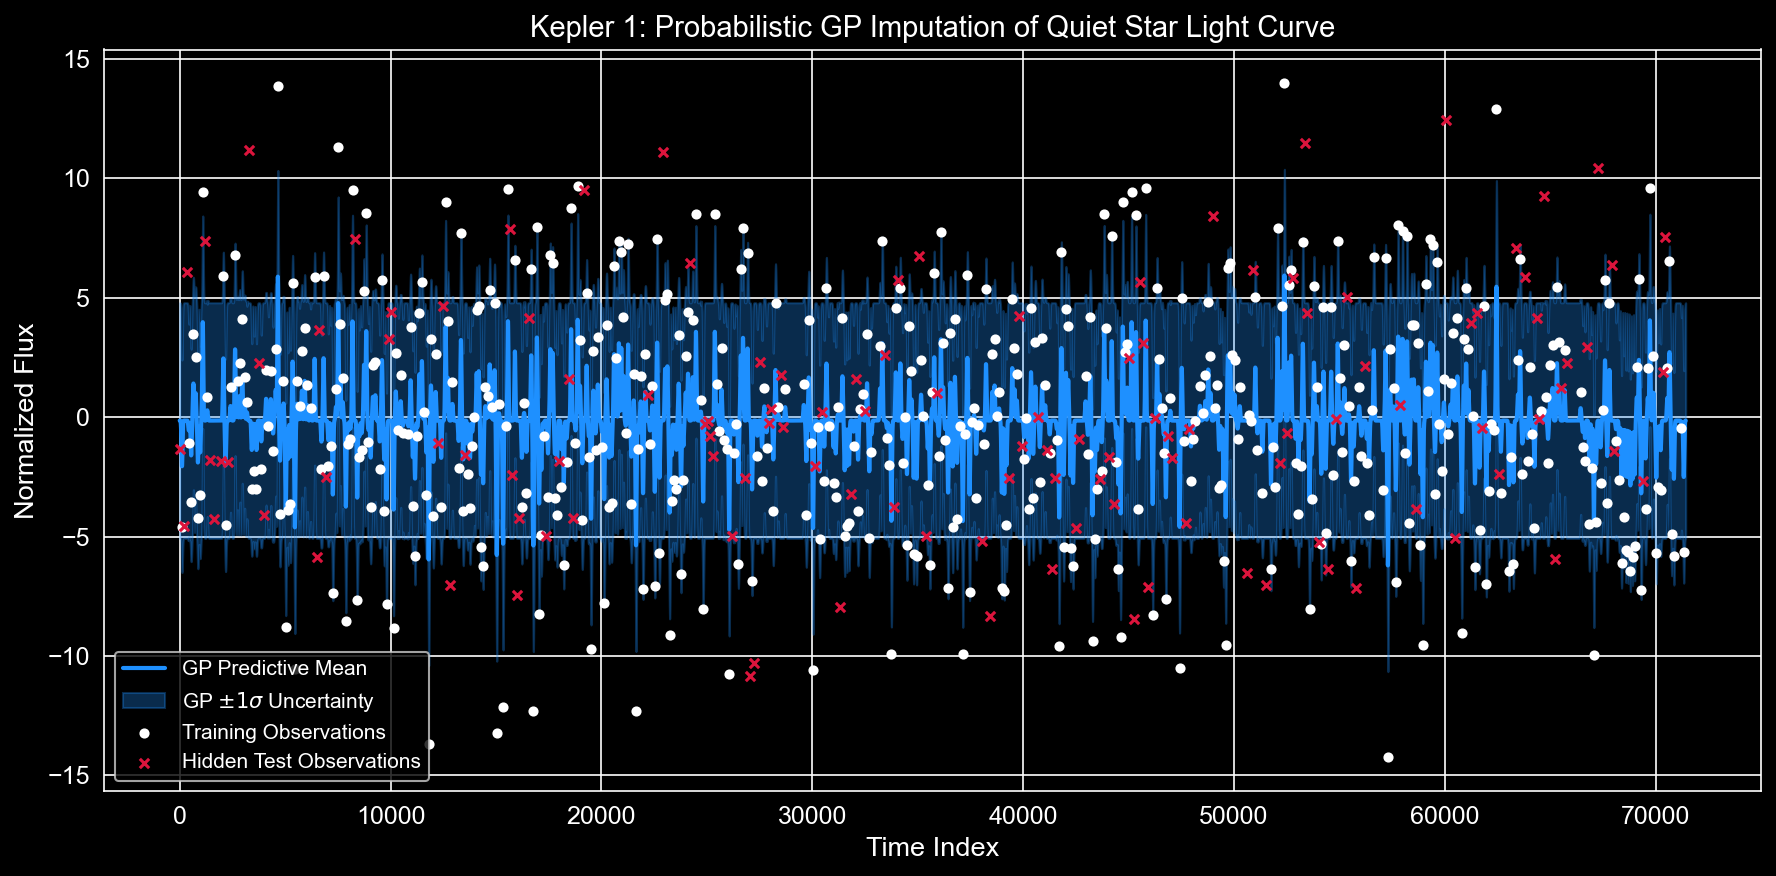

In [36]:
# --- Visualization of the Best GP Model Split for Kepler 1 ---

# Identify the representative seed closest to the mean RMSE
mean_rmse = np.mean(gp_rmse_list)
representative_idx = np.argmin(np.abs(np.array(gp_rmse_list) - mean_rmse))
representative_seed = seeds[representative_idx]

print(f"Generating visualization for Representative Kepler 1 Seed: {representative_seed} (RMSE: {gp_rmse_list[representative_idx]:.4f})")

# Step 2: Recreate the train/test split for that specific representative seed
t1_train_rep, t1_test_rep, y1_train_rep, y1_test_rep = train_test_split(
    t1_sub, y1_sub, test_size=0.2, random_state=representative_seed
)

X1_train_rep = t1_train_rep.reshape(-1, 1)

# Step 3: Retrain the GP model on the representative split
gpr1_rep = GaussianProcessRegressor(kernel=kernel1, alpha=1e-2, normalize_y=True, random_state=representative_seed)
gpr1_rep.fit(X1_train_rep, y1_train_rep)

# Step 4: Predict over the FULL original time range to generate the smooth background band
X1_all = t1.reshape(-1, 1)
y1_pred_all_rep, y1_std_all_rep = gpr1_rep.predict(X1_all, return_std=True)

# Publication-style Plotting
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t1, y1_pred_all_rep, color='dodgerblue', label='GP Predictive Mean', lw=2)
ax.fill_between(t1, y1_pred_all_rep - y1_std_all_rep, y1_pred_all_rep + y1_std_all_rep,
                color='dodgerblue', alpha=0.3, label=r'GP $\pm 1\sigma$ Uncertainty')

ax.scatter(t1_train_rep, y1_train_rep, color='white', s=15, label='Training Observations', zorder=3)
ax.scatter(t1_test_rep, y1_test_rep, color='crimson', s=20, marker='x', label='Hidden Test Observations', zorder=4)

ax.set_title("Kepler 1: Probabilistic GP Imputation of Quiet Star Light Curve")
ax.set_xlabel("Time Index")
ax.set_ylabel("Normalized Flux")
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig("figures/kepler1_gp_imputation.png", bbox_inches='tight')
plt.show()

Running Randomized Block Masking Evaluation...

--- Block Masking (Continuous Gap) Aggregates ---
Mean Gap RMSE: 5.0891 ± 0.2717
Mean Gap MAE:  4.1182 ± 0.2467
Mean Gap R^2 score: -0.0079 ± 0.0088
Mean 1σ Coverage: 64.08%
Mean 2σ Coverage: 95.83%


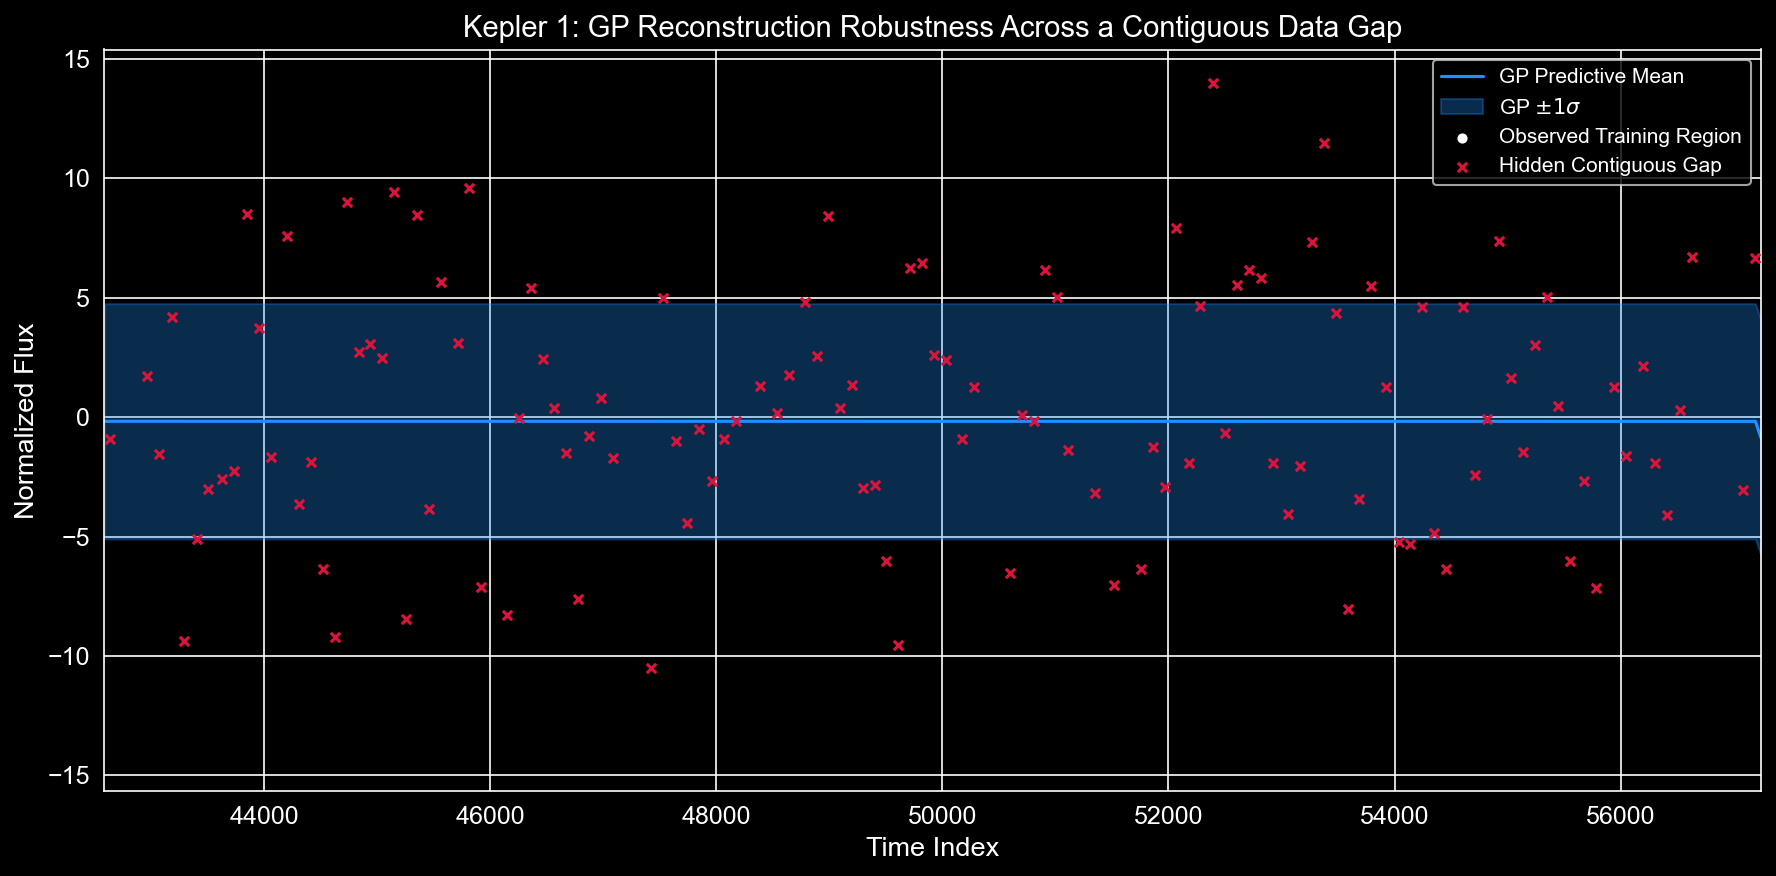

In [5]:
# --- RANDOMIZED BLOCK MASKING EXPERIMENT & VISUALIZATION ---
n_block_seeds = 20
block_size = int(len(t1_sub) * 0.2) # 20% continuous gap
max_start_idx = len(t1_sub) - block_size


gap_rmse_list, gap_mae_list, gap_r2_list, gap_1sigma_list, gap_2sigma_list = [], [], [], [], []
gap_predictions = []

print("Running Randomized Block Masking Evaluation...")

for seed in range(n_block_seeds):
    rng = np.random.RandomState(seed)
    start_idx = rng.randint(0, max_start_idx)
    end_idx = start_idx + block_size

    train_mask = np.ones(len(t1_sub), dtype=bool)
    train_mask[start_idx:end_idx] = False
    test_mask = ~train_mask

    t_train_gap, y_train_gap = t1_sub[train_mask], y1_sub[train_mask]
    t_test_gap, y_test_gap = t1_sub[test_mask], y1_sub[test_mask]

    gpr_gap = GaussianProcessRegressor(kernel=kernel1, alpha=1e-2, normalize_y=True, random_state=seed)
    gpr_gap.fit(t_train_gap.reshape(-1, 1), y_train_gap)
    y_pred_gap, y_std_gap = gpr_gap.predict(t_test_gap.reshape(-1, 1), return_std=True)

    # Evaluate
    gap_rmse_list.append(np.sqrt(mean_squared_error(y_test_gap, y_pred_gap)))
    gap_mae_list.append(mean_absolute_error(y_test_gap, y_pred_gap))
    gap_r2_list.append(r2_score(y_test_gap, y_pred_gap))
    gap_1sigma_list.append(np.mean((y_test_gap >= y_pred_gap - y_std_gap) & (y_test_gap <= y_pred_gap + y_std_gap)))
    gap_2sigma_list.append(np.mean((y_test_gap >= y_pred_gap - 2*y_std_gap) & (y_test_gap <= y_pred_gap + 2*y_std_gap)))

    gap_predictions.append({
        't_train': t_train_gap, 'y_train': y_train_gap,
        't_test': t_test_gap, 'y_test': y_test_gap,
        'gpr': gpr_gap
    })

print("\n--- Block Masking (Continuous Gap) Aggregates ---")
print(f"Mean Gap RMSE: {np.mean(gap_rmse_list):.4f} ± {np.std(gap_rmse_list):.4f}")
print(f"Mean Gap MAE:  {np.mean(gap_mae_list):.4f} ± {np.std(gap_mae_list):.4f}")
print(f"Mean Gap R^2 score: {np.mean(gap_r2_list):.4f} ± {np.std(gap_r2_list):.4f}")
print(f"Mean 1σ Coverage: {np.mean(gap_1sigma_list)*100:.2f}%")
print(f"Mean 2σ Coverage: {np.mean(gap_2sigma_list)*100:.2f}%")

# Plot Representative Gap Reconstruction
rep_gap_idx = np.argmin(np.abs(np.array(gap_rmse_list) - np.mean(gap_rmse_list)))
rep_gap = gap_predictions[rep_gap_idx]

# Predict smoothly over the specific gap area
t_plot_gap = np.linspace(rep_gap['t_test'].min() - 50, rep_gap['t_test'].max() + 50, 300)
y_plot_pred, y_plot_std = rep_gap['gpr'].predict(t_plot_gap.reshape(-1, 1), return_std=True)

plt.figure(figsize=(12, 6))
plt.plot(t_plot_gap, y_plot_pred, color='dodgerblue', label='GP Predictive Mean')
plt.fill_between(t_plot_gap, y_plot_pred - y_plot_std, y_plot_pred + y_plot_std, color='dodgerblue', alpha=0.3, label=r'GP $\pm 1\sigma$')
plt.scatter(rep_gap['t_train'], rep_gap['y_train'], color='white', s=15, label='Observed Training Region', zorder=3)
plt.scatter(rep_gap['t_test'], rep_gap['y_test'], color='crimson', s=20, marker='x', label='Hidden Contiguous Gap', zorder=4)

plt.xlim(t_plot_gap.min(), t_plot_gap.max())
plt.title("Kepler 1: GP Reconstruction Robustness Across a Contiguous Data Gap")
plt.xlabel("Time Index")
plt.ylabel("Normalized Flux")
plt.legend()
plt.tight_layout()
plt.savefig("figures/kepler1_block_gap_reconstruction.png", bbox_inches='tight')
plt.show()

### Modeling Structured Periodicity with `Kepler2.dat` using _Quasi-Periodic_ Kernel

> Mathematically, the `Quasi-Periodic Kernel` can be written as: <br>
$$
\gamma (t_i, t_j) = H_\mathrm{amp}^2  \exp{ \left \{-\frac{\sin^2{[\pi(t_i - t_j)/ P_\mathrm{rot}]}}{2 O_\mathrm{amp} ^2} - \frac{(t_i-t_j)^2}{2 P_\mathrm{dec}^2} \right \} }
$$

where, <br>
* $P_{\text{rot}}$ is the rotational period of the star
* $O_{\text{amp}}$ is the coherence scale
* $P_{\text{dec}}$ is the decay time scale of the active regions
* $H_{\text{amp}}$ is the amplitude of the kernel

In [24]:
from sklearn.gaussian_process.kernels import ExpSineSquared, ConstantKernel, RBF, WhiteKernel

# --- Kepler 2: Standard vs Quasi-Periodic Evaluation ---
# Step 1: Load and isolate valid data
flux2 = np.genfromtxt("datasets/Kepler2.dat", dtype=np.float32, missing_values="NA", filling_values=np.nan)
t2 = np.arange(len(flux2))

mask2 = ~np.isnan(flux2)
t2_valid = t2[mask2]
y2_valid = flux2[mask2]

# Subsample due to memory limitations
subset2 = 50
t2_sub = t2_valid[::subset2]
y2_sub = y2_valid[::subset2]
print(len(t2_sub))


1017 1017


In [17]:
n_k2_seeds = 20

rbf_rmse_list, rbf_mae_list = [], []
qp_rmse_list, qp_mae_list = [], []

rbf_kernel2 = 1.0 * RBF(length_scale=100.0) + WhiteKernel(noise_level=1.0)
qp_kernel2 = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * ExpSineSquared(
        length_scale=10.0,
        periodicity=150.0,
        length_scale_bounds=(1e-2, 1e4),
        periodicity_bounds=(10.0, 1e4)
    )
    * RBF(
        length_scale=200.0,
        length_scale_bounds=(1e-2, 1e5)
    )
    + WhiteKernel(
        noise_level=1.0,
        noise_level_bounds=(1e-6, 1e2)
    )
)

In [39]:

print(f"Evaluating kernels on Kepler 2 across {n_k2_seeds} seeds...")

for seed in range(n_k2_seeds):
    t2_train, t2_test, y2_train, y2_test = train_test_split(t2_sub, y2_sub, test_size=0.2, random_state=seed)
    X2_train, X2_test = t2_train.reshape(-1, 1), t2_test.reshape(-1, 1)

    # RBF Baseline
    gpr2_rbf = GaussianProcessRegressor(kernel=rbf_kernel2, alpha=1e-2, normalize_y=True, random_state=seed)
    gpr2_rbf.fit(X2_train, y2_train)
    y_pred_rbf = gpr2_rbf.predict(X2_test)

    rbf_rmse_list.append(np.sqrt(mean_squared_error(y2_test, y_pred_rbf)))
    rbf_mae_list.append(mean_absolute_error(y2_test, y_pred_rbf))

    # Quasi-Periodic Target
    gpr2_qp = GaussianProcessRegressor(kernel=qp_kernel2, alpha=1e-2, normalize_y=True, random_state=seed)
    gpr2_qp.fit(X2_train, y2_train)
    y_pred_qp = gpr2_qp.predict(X2_test)

    qp_rmse_list.append(np.sqrt(mean_squared_error(y2_test, y_pred_qp)))
    qp_mae_list.append(mean_absolute_error(y2_test, y_pred_qp))

# --- Kepler 2 Summary Table ---
k2_benchmark_data = {
    "Kernel Method": ["RBF (Standard)", "Quasi-Periodic"],
    "RMSE Mean": [np.mean(rbf_rmse_list), np.mean(qp_rmse_list)],
    "RMSE Std": [np.std(rbf_rmse_list), np.std(qp_rmse_list)],
    "MAE Mean": [np.mean(rbf_mae_list), np.mean(qp_mae_list)],
    "MAE Std": [np.std(rbf_mae_list), np.std(qp_mae_list)]
}

k2_benchmark_df = pd.DataFrame(k2_benchmark_data)
print("\n--- Kepler 2 Kernel Robustness Comparison ---")
display.display(k2_benchmark_df.round(4))

Evaluating kernels on Kepler 2 across 20 seeds...


/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1


--- Kepler 2 Kernel Robustness Comparison ---


/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,Kernel Method,RMSE Mean,RMSE Std,MAE Mean,MAE Std
0,RBF (Standard),36.5371,9.0953,16.7843,2.1005
1,Quasi-Periodic,36.5366,9.0955,16.7836,2.1005


### --- KEPLER 2: ADVANCED VISUALIZATIONS & DIAGNOSTICS ---


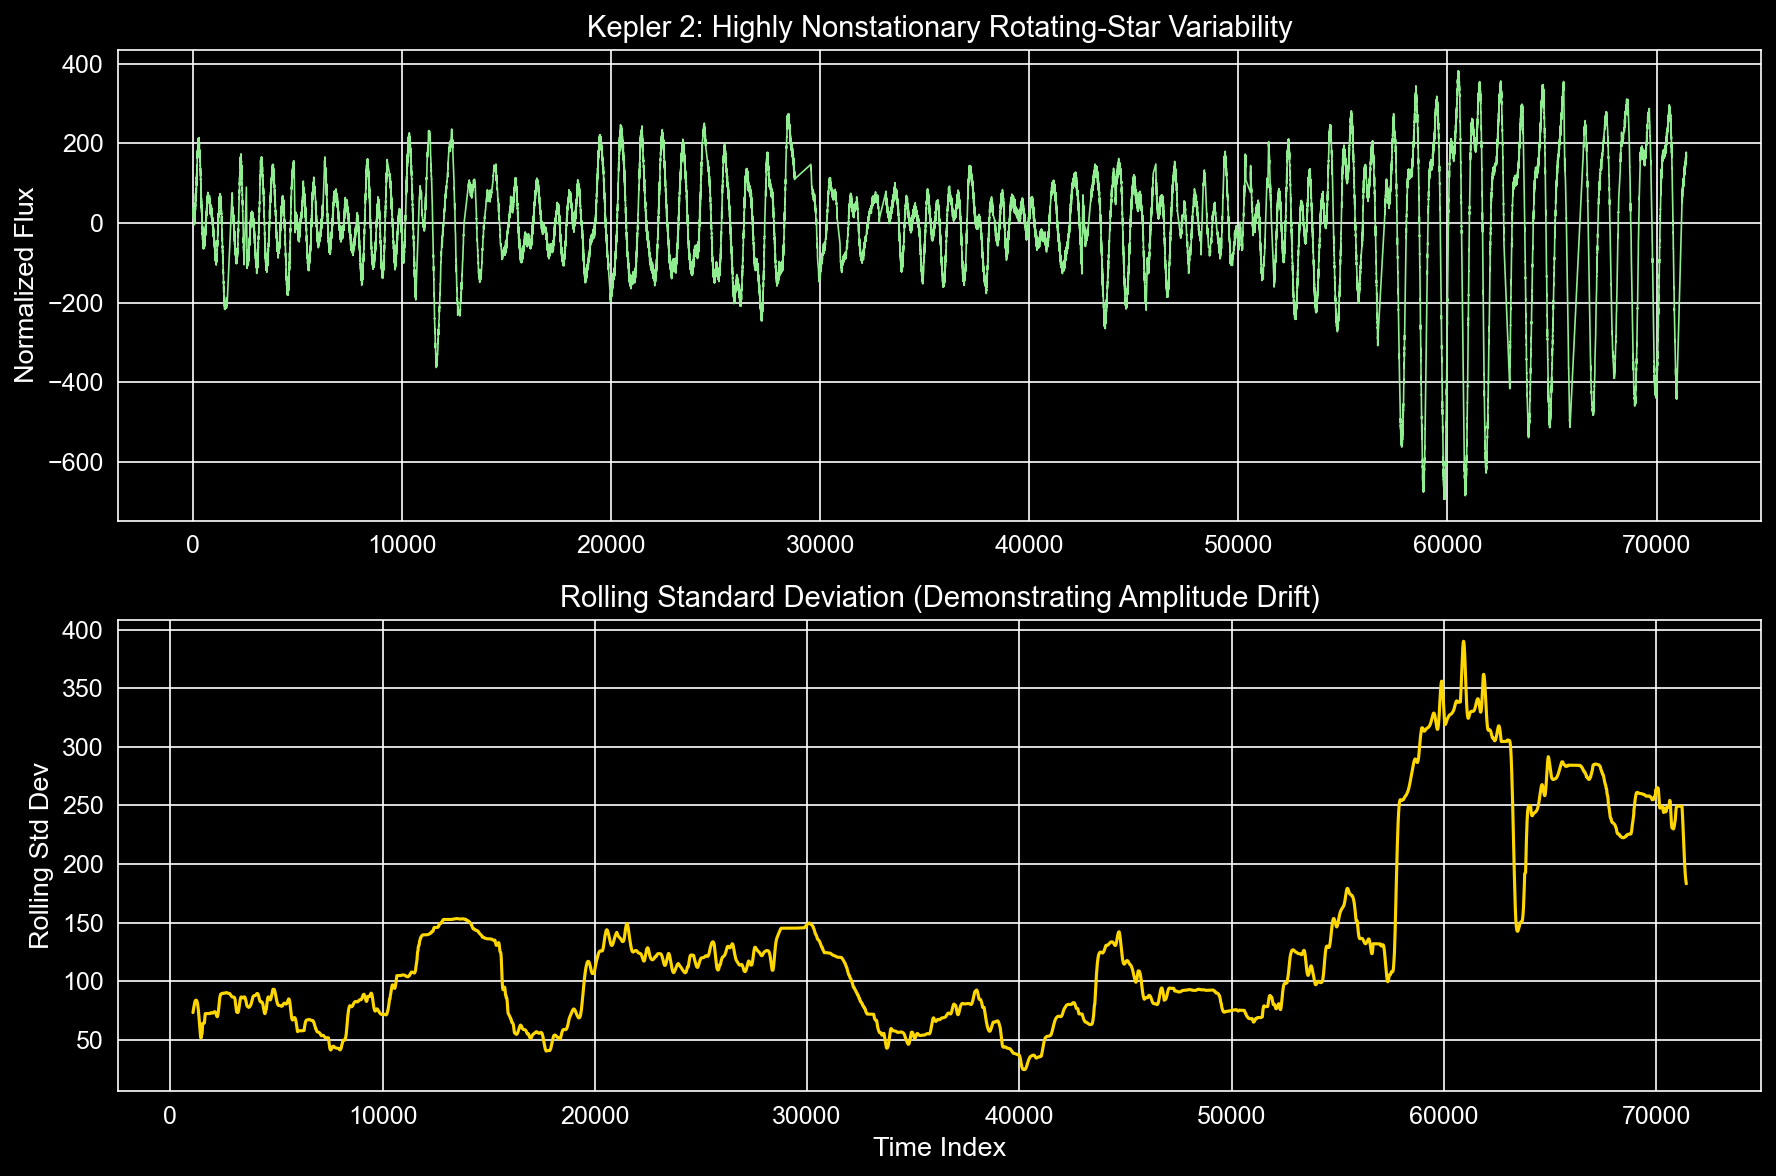

In [40]:
# 1. Nonstationarity Visualization
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(t2_valid, y2_valid, color='lightgreen', lw=0.8)
plt.title("Kepler 2: Highly Nonstationary Rotating-Star Variability")
plt.ylabel("Normalized Flux")

plt.subplot(2, 1, 2)
rolling_std = pd.Series(y2_valid).rolling(window=1000).std()
plt.plot(t2_valid, rolling_std, color='gold', lw=1.5)
plt.title("Rolling Standard Deviation (Demonstrating Amplitude Drift)")
plt.xlabel("Time Index")
plt.ylabel("Rolling Std Dev")
plt.tight_layout()
plt.savefig("figures/kepler2_nonstationarity.png", bbox_inches='tight')
plt.show()

/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


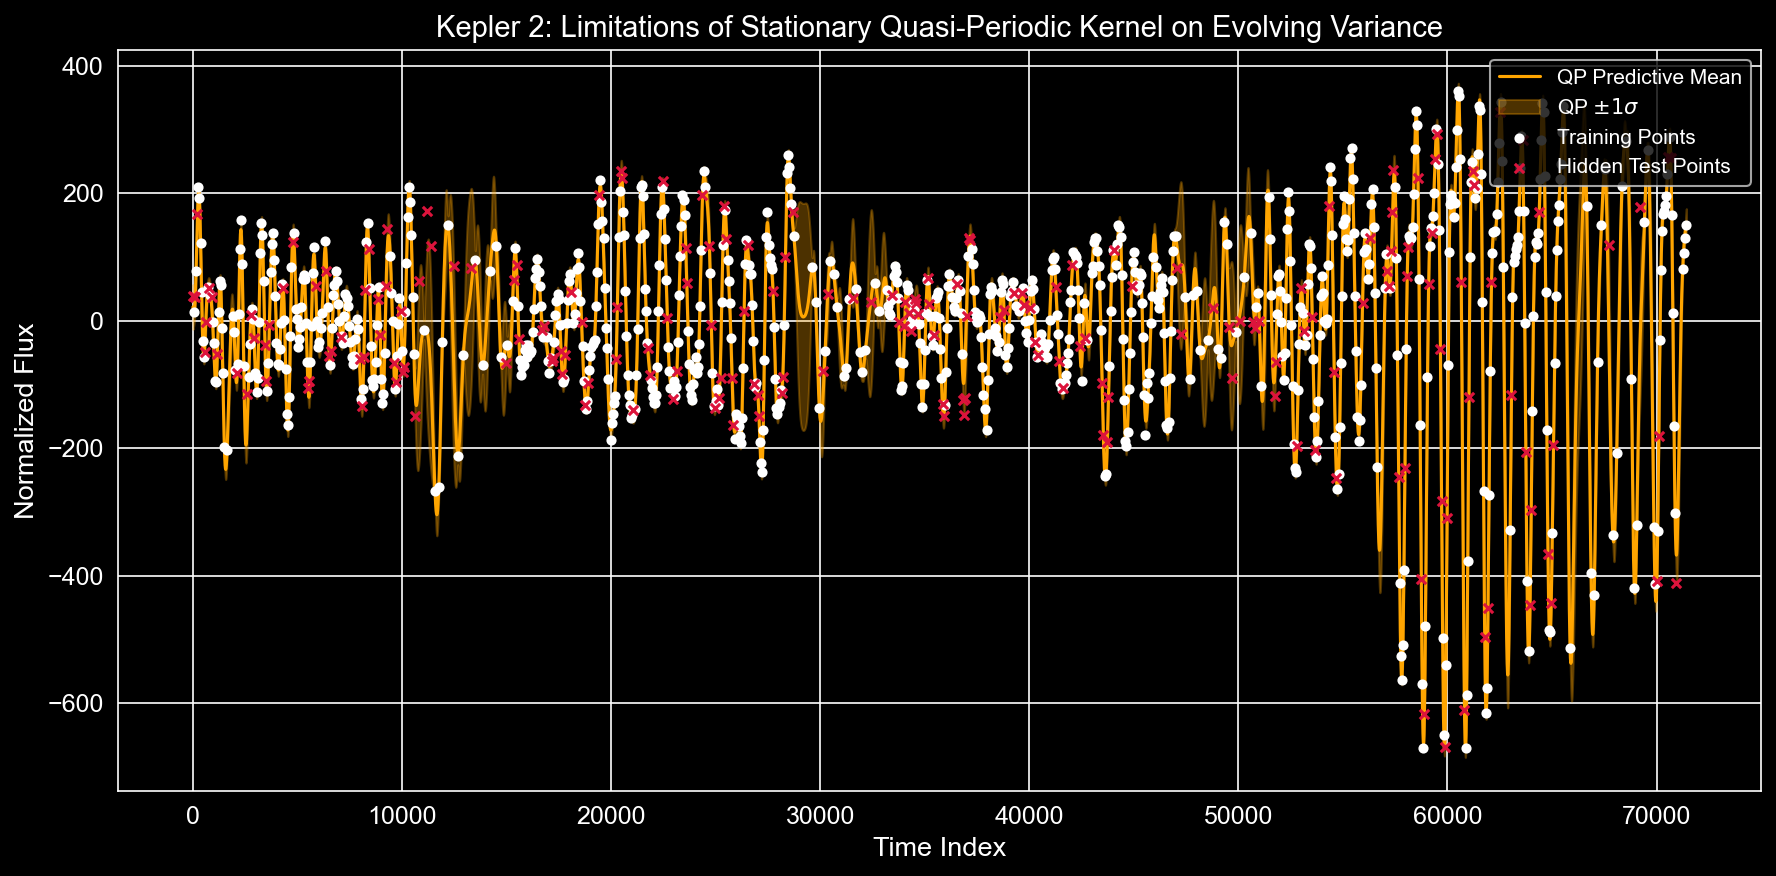

In [41]:
# 2. Representative QP Kernel Limitation Visualization
rep_qp_idx = np.argmin(np.abs(np.array(qp_rmse_list) - np.mean(qp_rmse_list)))
t2_train_rep, t2_test_rep, y2_train_rep, y2_test_rep = train_test_split(t2_sub, y2_sub, test_size=0.2, random_state=rep_qp_idx)

gpr2_qp_rep = GaussianProcessRegressor(kernel=qp_kernel2, alpha=1e-2, normalize_y=True, random_state=rep_qp_idx)
gpr2_qp_rep.fit(t2_train_rep.reshape(-1, 1), y2_train_rep)
y2_pred_all_qp, y2_std_all_qp = gpr2_qp_rep.predict(t2.reshape(-1, 1), return_std=True)

plt.figure(figsize=(12, 6))
plt.plot(t2, y2_pred_all_qp, color='orange', lw=1.5, label='QP Predictive Mean')
plt.fill_between(t2, y2_pred_all_qp - y2_std_all_qp, y2_pred_all_qp + y2_std_all_qp, color='orange', alpha=0.3, label=r'QP $\pm 1\sigma$')
plt.scatter(t2_train_rep, y2_train_rep, color='white', s=15, label='Training Points', zorder=3)
plt.scatter(t2_test_rep, y2_test_rep, color='crimson', s=20, marker='x', label='Hidden Test Points', zorder=4)

plt.title("Kepler 2: Limitations of Stationary Quasi-Periodic Kernel on Evolving Variance")
plt.xlabel("Time Index")
plt.ylabel("Normalized Flux")
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("figures/kepler2_qp_limitation.png", bbox_inches='tight')
plt.show()

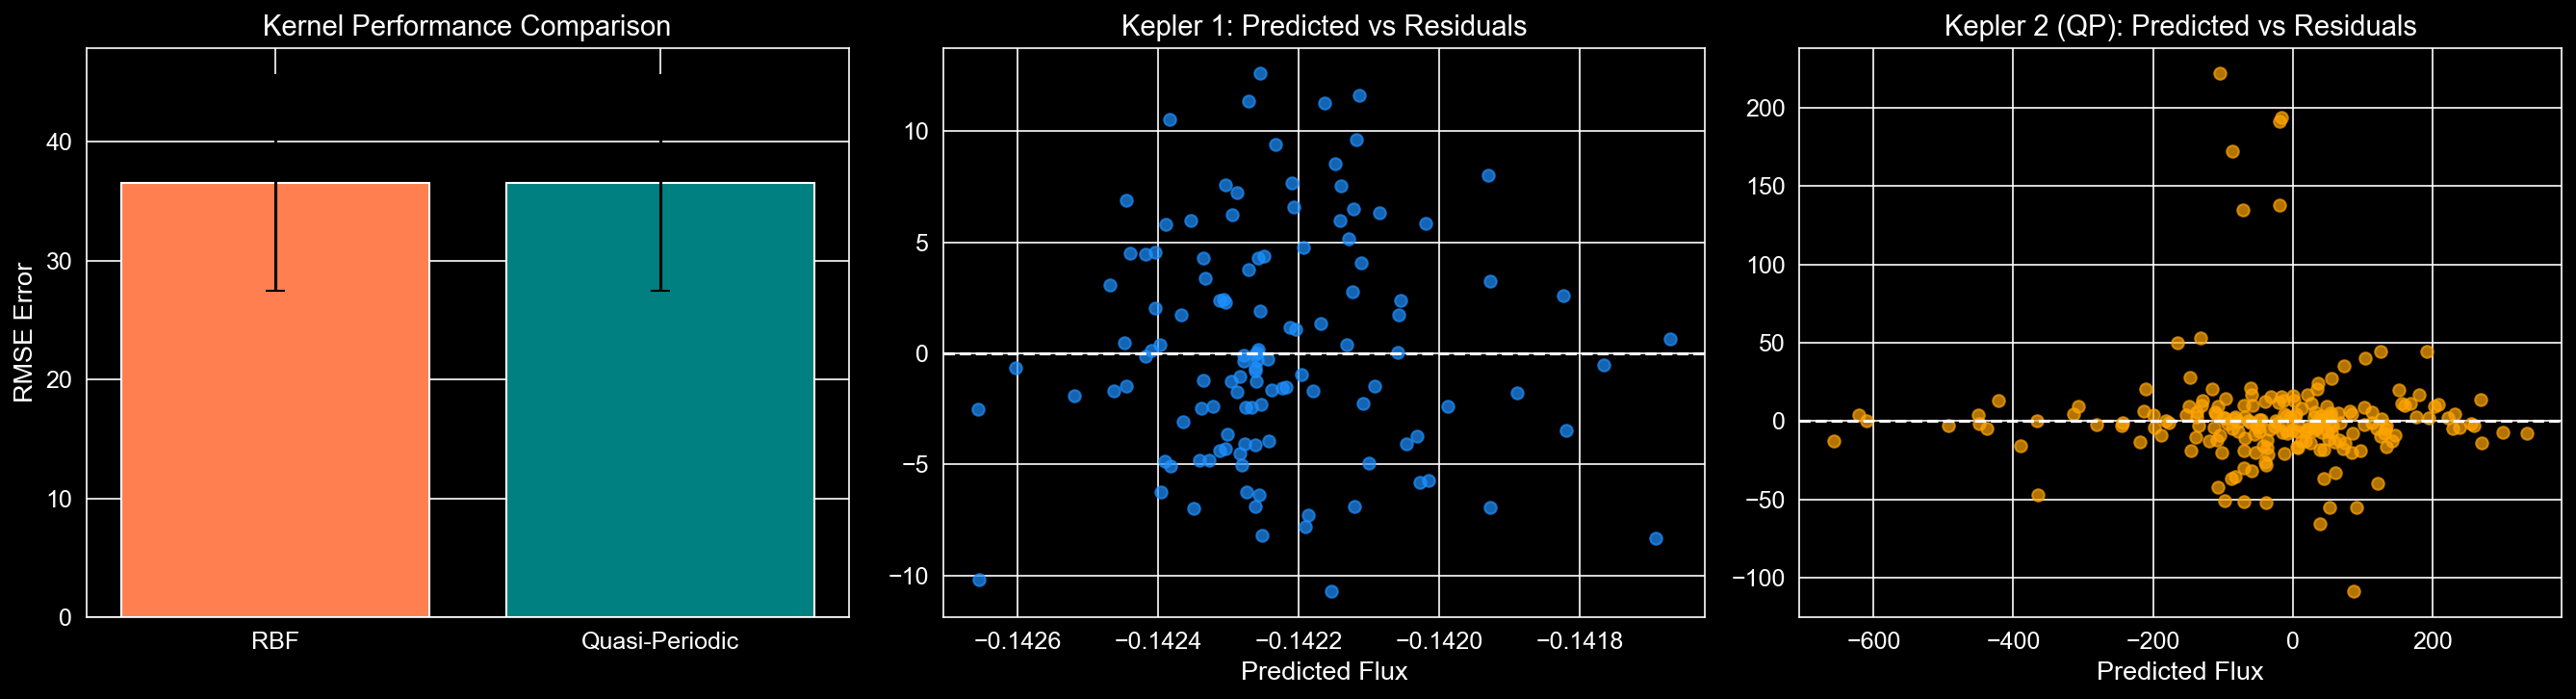

In [42]:
# 3. Kernel Comparison & Residual Diagnostics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Kernel Comparison
kernels = ["RBF", "Quasi-Periodic"]
rmse_means_k2 = [np.mean(rbf_rmse_list), np.mean(qp_rmse_list)]
rmse_stds_k2 = [np.std(rbf_rmse_list), np.std(qp_rmse_list)]
axes[0].bar(kernels, rmse_means_k2, yerr=rmse_stds_k2, capsize=5, color=['coral', 'teal'])
axes[0].set_ylabel("RMSE Error")
axes[0].set_title("Kernel Performance Comparison")

# Kepler 1 Residuals (Using rep model from earlier)
y1_test_pred = gpr1_rep.predict(t1_test_rep.reshape(-1, 1))
res1 = y1_test_rep - y1_test_pred
axes[1].scatter(y1_test_pred, res1, color='dodgerblue', alpha=0.7)
axes[1].axhline(0, color='white', linestyle='--')
axes[1].set_title("Kepler 1: Predicted vs Residuals")
axes[1].set_xlabel("Predicted Flux")

# Kepler 2 QP Residuals
y2_test_pred = gpr2_qp_rep.predict(t2_test_rep.reshape(-1, 1))
res2 = y2_test_rep - y2_test_pred
axes[2].scatter(y2_test_pred, res2, color='orange', alpha=0.7)
axes[2].axhline(0, color='white', linestyle='--')
axes[2].set_title("Kepler 2 (QP): Predicted vs Residuals")
axes[2].set_xlabel("Predicted Flux")

plt.tight_layout()
plt.savefig("figures/kepler_diagnostics_and_comparison.png", bbox_inches='tight')
plt.show()

---
## Change-Point Gaussian Process: Piecewise Stationary Modelling of Kepler 2

The quasi-periodic kernel above reveals a key limitation: the amplitude of Kepler 2's variability
is **not** constant over time — it grows noticeably past a certain epoch. A single stationary (or
globally quasi-periodic) covariance function cannot simultaneously fit both the low-variance early
segment and the high-variance later segment.

**Strategy** — detect a variance regime shift automatically, then fit *independent* GPs on each
piecewise-stationary segment and splice the predictions together.  The approach:

1. Compute a rolling standard-deviation profile of the observed flux.
2. Locate the first index where the rolling std permanently exceeds a threshold (mean + 0.5 × std
   of the profile) — this becomes the **change-point** τ.
3. Fit **GP₁** on observations with `t < τ` and **GP₂** on observations with `t ≥ τ`, each with an
   independent quasi-periodic kernel that can tune its own amplitude, length-scale, and period.
4. At prediction time, route each query point to its respective segment GP.
5. Run the same Monte Carlo random-masking experiment (20–50 trials) used for Kepler 1 and compare
   against the globally stationary QP baseline.


In [12]:
# ── Change-Point Detection via Rolling Variance Shift ──────────────────────────────

# Re-use the valid Kepler 2 arrays already built in prior cells:
#   t2_valid  – time indices of all non-NaN observations
#   y2_valid  – corresponding flux values

ROLLING_WIN = 1000  # same window used in the nonstationarity plot above

rolling_std_full = pd.Series(y2_valid).rolling(window=ROLLING_WIN, center=False).std()

# Drop the warm-up NaNs introduced by the rolling window
valid_roll_mask = ~rolling_std_full.isna().values
t_roll    = t2_valid[valid_roll_mask]
std_roll  = rolling_std_full[valid_roll_mask].values

# Threshold: mean + 0.5 × std of the rolling-std profile
roll_threshold = std_roll.mean() + 0.5 * std_roll.std()

# First time index where the rolling std *permanently* exceeds the threshold
exceed_idx = np.where(std_roll > roll_threshold)[0]
if len(exceed_idx) == 0:
    raise RuntimeError("No variance shift detected — adjust ROLLING_WIN or threshold.")
cp_roll_idx  = exceed_idx[0]          # position in the *rolled* arrays
cp_time      = int(t_roll[cp_roll_idx])  # absolute time index

print(f"Variance-shift threshold : {roll_threshold:.4f}")
print(f"Detected change-point τ  : time index {cp_time}")
print(f"Segment 1 observations   : {(t2_valid < cp_time).sum()}")
print(f"Segment 2 observations   : {(t2_valid >= cp_time).sum()}")


Variance-shift threshold : 166.7497
Detected change-point τ  : time index 55318
Segment 1 observations   : 39907
Segment 2 observations   : 10922


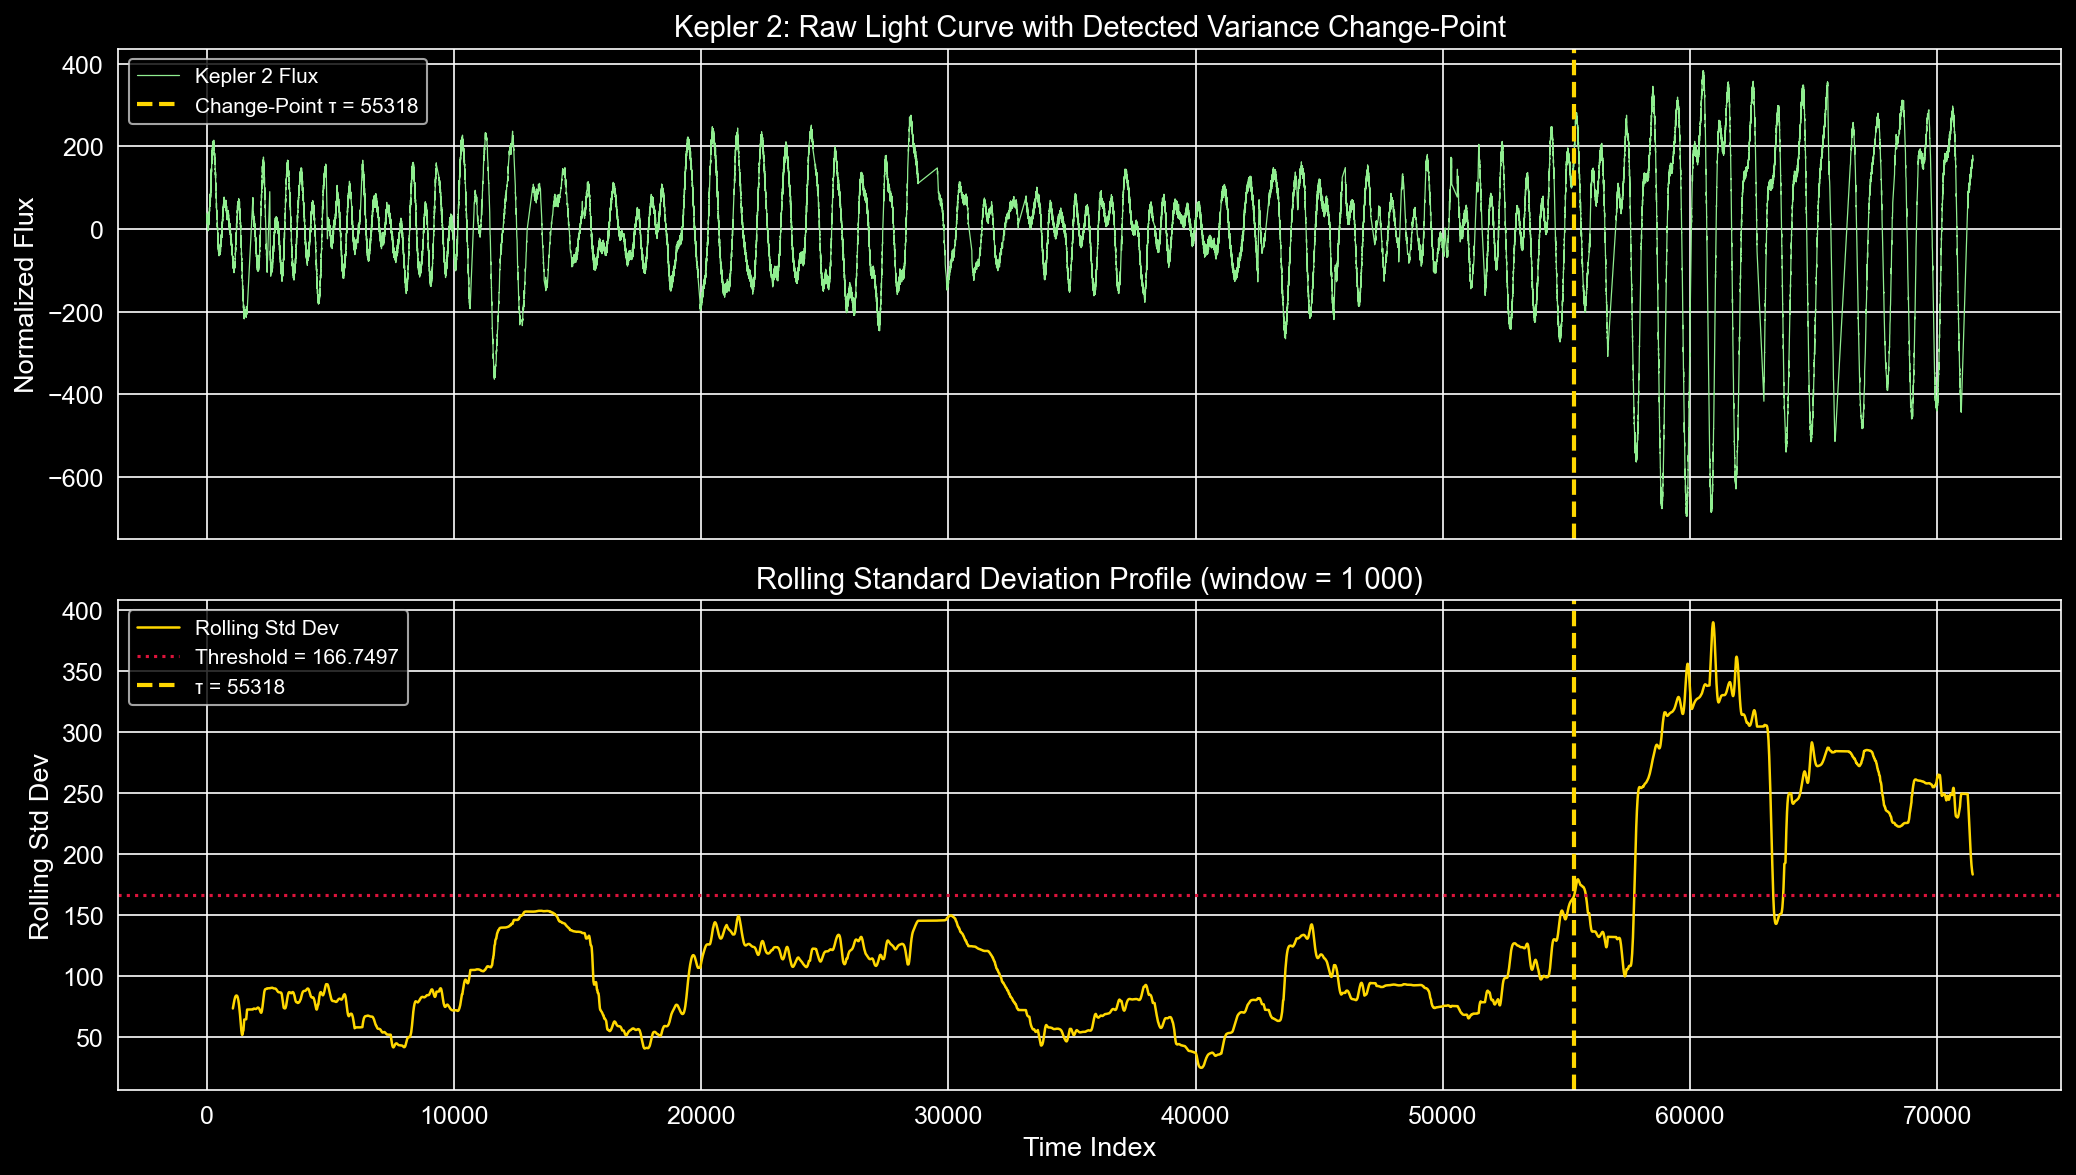

In [13]:
# ── Visualise Detected Change-Point ────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1 – raw light curve with change-point marker
axes[0].plot(t2_valid, y2_valid, color='lightgreen', lw=0.6, label='Kepler 2 Flux')
axes[0].axvline(cp_time, color='gold', lw=2, linestyle='--', label=f'Change-Point τ = {cp_time}')
axes[0].set_ylabel('Normalized Flux')
axes[0].set_title('Kepler 2: Raw Light Curve with Detected Variance Change-Point')
axes[0].legend(loc='upper left')

# Panel 2 – rolling std profile with threshold
axes[1].plot(t_roll, std_roll, color='gold', lw=1.2, label='Rolling Std Dev')
axes[1].axhline(roll_threshold, color='crimson', lw=1.5, linestyle=':', label=f'Threshold = {roll_threshold:.4f}')
axes[1].axvline(cp_time, color='gold', lw=2, linestyle='--', label=f'τ = {cp_time}')
axes[1].set_xlabel('Time Index')
axes[1].set_ylabel('Rolling Std Dev')
axes[1].set_title('Rolling Standard Deviation Profile (window = 1 000)')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig('figures/kepler2_change_point_detection.png', bbox_inches='tight')
plt.show()


In [18]:
# ── Change-Point GP: Monte Carlo Random-Masking Evaluation ─────────────────────────
# We use the same subsampled arrays (t2_sub, y2_sub) and the same 20-seed protocol
# as the stationary QP baseline above so the comparison is apples-to-apples.

from scipy.stats import norm as sp_norm

# ── Piecewise GP helper ──────────────────────────────────────────────────────────────
def fit_predict_cp_gp(t_train, y_train, t_test, cp_time, seed):
    """
    Fit two independent quasi-periodic GPs — one per segment — and
    return spliced predictions (mean, std) evaluated at t_test.

    Parameters
    ----------
    t_train, y_train : training time indices and flux values
    t_test           : query time indices
    cp_time          : scalar change-point (absolute time index)
    seed             : random seed for reproducibility

    Returns
    -------
    y_pred : ndarray, shape (len(t_test),)
    y_std  : ndarray, shape (len(t_test),)
    """
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import (
        ConstantKernel, ExpSineSquared, RBF, WhiteKernel
    )

    def _qp_kernel():
        return (
            ConstantKernel(1.0, (1e-3, 1e3))
            * ExpSineSquared(
                length_scale=10.0, periodicity=150.0,
                length_scale_bounds=(1e-2, 1e4),
                periodicity_bounds=(10.0, 1e4)
            )
            * RBF(length_scale=200.0, length_scale_bounds=(1e-2, 1e5))
            + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-6, 1e2))
        )

    y_pred = np.full(len(t_test), np.nan)
    y_std  = np.full(len(t_test), np.nan)

    for seg_mask_train, seg_mask_test in [
        (t_train < cp_time,  t_test < cp_time),   # Segment 1
        (t_train >= cp_time, t_test >= cp_time),   # Segment 2
    ]:
        t_seg_train = t_train[seg_mask_train]
        y_seg_train = y_train[seg_mask_train]
        t_seg_test  = t_test[seg_mask_test]

        # Need at least 2 training points per segment to fit
        if len(t_seg_train) < 2 or len(t_seg_test) == 0:
            continue

        gpr_seg = GaussianProcessRegressor(
            kernel=_qp_kernel(), alpha=1e-2,
            normalize_y=True, random_state=seed
        )
        gpr_seg.fit(t_seg_train.reshape(-1, 1), y_seg_train)
        mu, sigma = gpr_seg.predict(t_seg_test.reshape(-1, 1), return_std=True)
        y_pred[seg_mask_test] = mu
        y_std[seg_mask_test]  = sigma

    return y_pred, y_std


# ── Evaluation loop ─────────────────────────────────────────────────────────────────
n_cp_seeds = 20   # same budget as prior experiments

cp_rmse_list, cp_mae_list, cp_r2_list = [], [], []
cp_nlpd_list = []   # negative log predictive density
cp_1sigma_list, cp_2sigma_list = [], []

# Store the same for the stationary QP (already evaluated above but re-run cleanly
# here for a fair apples-to-apples comparison under identical seeds)
stat_rmse_list2, stat_mae_list2, stat_r2_list2 = [], [], []
stat_nlpd_list2 = []
stat_1sigma_list2, stat_2sigma_list2 = [], []

print(f"Running Change-Point GP evaluation across {n_cp_seeds} seeds...")

for seed in range(n_cp_seeds):
    t2_tr, t2_te, y2_tr, y2_te = train_test_split(
        t2_sub, y2_sub, test_size=0.2, random_state=seed
    )

    # ── Stationary QP baseline (re-evaluated under same seed) ───────────────────────
    gpr_stat = GaussianProcessRegressor(
        kernel=qp_kernel2, alpha=1e-2, normalize_y=True, random_state=seed
    )
    gpr_stat.fit(t2_tr.reshape(-1, 1), y2_tr)
    y_stat_pred, y_stat_std = gpr_stat.predict(t2_te.reshape(-1, 1), return_std=True)

    stat_rmse_list2.append(np.sqrt(mean_squared_error(y2_te, y_stat_pred)))
    stat_mae_list2.append(mean_absolute_error(y2_te, y_stat_pred))
    stat_r2_list2.append(r2_score(y2_te, y_stat_pred))
    # NLPD: negative log predictive density under a Gaussian predictive
    stat_nlpd_list2.append(
        -np.mean(sp_norm.logpdf(y2_te, loc=y_stat_pred, scale=np.clip(y_stat_std, 1e-8, None)))
    )
    stat_1sigma_list2.append(
        np.mean((y2_te >= y_stat_pred - y_stat_std) & (y2_te <= y_stat_pred + y_stat_std))
    )
    stat_2sigma_list2.append(
        np.mean((y2_te >= y_stat_pred - 2*y_stat_std) & (y2_te <= y_stat_pred + 2*y_stat_std))
    )

    # ── Change-Point GP ─────────────────────────────────────────────────────────────
    y_cp_pred, y_cp_std = fit_predict_cp_gp(t2_tr, y2_tr, t2_te, cp_time, seed)

    valid = ~np.isnan(y_cp_pred)   # guard against empty segments
    if valid.sum() < 2:
        continue

    cp_rmse_list.append(np.sqrt(mean_squared_error(y2_te[valid], y_cp_pred[valid])))
    cp_mae_list.append(mean_absolute_error(y2_te[valid], y_cp_pred[valid]))
    cp_r2_list.append(r2_score(y2_te[valid], y_cp_pred[valid]))
    cp_nlpd_list.append(
        -np.mean(sp_norm.logpdf(
            y2_te[valid],
            loc=y_cp_pred[valid],
            scale=np.clip(y_cp_std[valid], 1e-8, None)
        ))
    )
    cp_1sigma_list.append(
        np.mean((y2_te[valid] >= y_cp_pred[valid] - y_cp_std[valid]) &
                (y2_te[valid] <= y_cp_pred[valid] + y_cp_std[valid]))
    )
    cp_2sigma_list.append(
        np.mean((y2_te[valid] >= y_cp_pred[valid] - 2*y_cp_std[valid]) &
                (y2_te[valid] <= y_cp_pred[valid] + 2*y_cp_std[valid]))
    )

print("Evaluation complete.")


Running Change-Point GP evaluation across 20 seeds...


/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1

Evaluation complete.


/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [19]:
# ── Statistical Comparison Table ───────────────────────────────────────────────────

import IPython.display as display

cp_comparison_data = {
    "Model": ["Stationary QP GP", "Change-Point GP"],
    "RMSE Mean": [np.mean(stat_rmse_list2), np.mean(cp_rmse_list)],
    "RMSE Std":  [np.std(stat_rmse_list2),  np.std(cp_rmse_list)],
    "MAE Mean":  [np.mean(stat_mae_list2),  np.mean(cp_mae_list)],
    "MAE Std":   [np.std(stat_mae_list2),   np.std(cp_mae_list)],
    "R² Mean":   [np.mean(stat_r2_list2),   np.mean(cp_r2_list)],
    "R² Std":    [np.std(stat_r2_list2),    np.std(cp_r2_list)],
    "NLPD Mean": [np.mean(stat_nlpd_list2), np.mean(cp_nlpd_list)],
    "NLPD Std":  [np.std(stat_nlpd_list2),  np.std(cp_nlpd_list)],
    "1σ Coverage": [
        f"{np.mean(stat_1sigma_list2)*100:.1f}% ± {np.std(stat_1sigma_list2)*100:.1f}%",
        f"{np.mean(cp_1sigma_list)*100:.1f}% ± {np.std(cp_1sigma_list)*100:.1f}%"
    ],
    "2σ Coverage": [
        f"{np.mean(stat_2sigma_list2)*100:.1f}% ± {np.std(stat_2sigma_list2)*100:.1f}%",
        f"{np.mean(cp_2sigma_list)*100:.1f}% ± {np.std(cp_2sigma_list)*100:.1f}%"
    ],
}

cp_df = pd.DataFrame(cp_comparison_data)
print("\n─── Kepler 2 Model Comparison: Stationary QP vs Change-Point GP ───")
display.display(cp_df.round(4))

# Summary commentary
delta_rmse = np.mean(stat_rmse_list2) - np.mean(cp_rmse_list)
delta_nlpd = np.mean(stat_nlpd_list2) - np.mean(cp_nlpd_list)
print(f"\nΔ RMSE  (stat − CP): {delta_rmse:+.4f}  {'→ CP better' if delta_rmse > 0 else '→ Stationary better'}")
print(f"Δ NLPD  (stat − CP): {delta_nlpd:+.4f}  {'→ CP better' if delta_nlpd > 0 else '→ Stationary better'}")



─── Kepler 2 Model Comparison: Stationary QP vs Change-Point GP ───


,Model,RMSE Mean,RMSE Std,MAE Mean,MAE Std,R² Mean,R² Std,NLPD Mean,NLPD Std,1σ Coverage,2σ Coverage
0,Stationary QP GP,36.5366,9.0955,16.7836,2.1005,0.9399,0.029,4.1797,0.0613,76.9% ± 2.1%,97.7% ± 0.9%
1,Change-Point GP,36.5840,9.6892,16.8054,2.0788,0.9394,0.031,4.2008,0.0752,71.2% ± 2.4%,94.7% ± 1.4%



Δ RMSE  (stat − CP): -0.0474  → Stationary better
Δ NLPD  (stat − CP): -0.0211  → Stationary better


In [20]:
# ── Representative CP-GP Reconstruction Visualization ──────────────────────────────
# Retrain the CP-GP on the seed closest to the median RMSE

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, ExpSineSquared, RBF, WhiteKernel

def _qp_kernel_fresh():
    return (
        ConstantKernel(1.0, (1e-3, 1e3))
        * ExpSineSquared(
            length_scale=10.0, periodicity=150.0,
            length_scale_bounds=(1e-2, 1e4),
            periodicity_bounds=(10.0, 1e4)
        )
        * RBF(length_scale=200.0, length_scale_bounds=(1e-2, 1e5))
        + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-6, 1e2))
    )

# Identify representative seed for the CP-GP
median_cp_rmse   = np.median(cp_rmse_list)
rep_cp_seed_idx  = np.argmin(np.abs(np.array(cp_rmse_list) - median_cp_rmse))
rep_cp_seed      = rep_cp_seed_idx

t2_tr_rep, t2_te_rep, y2_tr_rep, y2_te_rep = train_test_split(
    t2_sub, y2_sub, test_size=0.2, random_state=rep_cp_seed
)

# ── Fit segment GPs on training data ────────────────────────────────────────────────
seg1_tr_mask = t2_tr_rep < cp_time
seg2_tr_mask = t2_tr_rep >= cp_time

gpr_seg1 = GaussianProcessRegressor(kernel=_qp_kernel_fresh(), alpha=1e-2,
                                     normalize_y=True, random_state=rep_cp_seed)
gpr_seg1.fit(t2_tr_rep[seg1_tr_mask].reshape(-1, 1), y2_tr_rep[seg1_tr_mask])

gpr_seg2 = GaussianProcessRegressor(kernel=_qp_kernel_fresh(), alpha=1e-2,
                                     normalize_y=True, random_state=rep_cp_seed)
gpr_seg2.fit(t2_tr_rep[seg2_tr_mask].reshape(-1, 1), y2_tr_rep[seg2_tr_mask])

# ── Dense prediction over the full time range ────────────────────────────────────────
t2_dense       = np.linspace(t2.min(), t2.max(), 600)
seg1_pred_mask = t2_dense < cp_time
seg2_pred_mask = t2_dense >= cp_time

y_cp_dense      = np.full(len(t2_dense), np.nan)
y_cp_std_dense  = np.full(len(t2_dense), np.nan)

mu1, s1 = gpr_seg1.predict(t2_dense[seg1_pred_mask].reshape(-1, 1), return_std=True)
mu2, s2 = gpr_seg2.predict(t2_dense[seg2_pred_mask].reshape(-1, 1), return_std=True)

y_cp_dense[seg1_pred_mask]     = mu1
y_cp_dense[seg2_pred_mask]     = mu2
y_cp_std_dense[seg1_pred_mask] = s1
y_cp_std_dense[seg2_pred_mask] = s2

# ── Also get the stationary QP prediction over same dense grid ──────────────────────
gpr_stat_rep = GaussianProcessRegressor(kernel=qp_kernel2, alpha=1e-2,
                                         normalize_y=True, random_state=rep_cp_seed)
gpr_stat_rep.fit(t2_tr_rep.reshape(-1, 1), y2_tr_rep)
y_stat_dense, y_stat_std_dense = gpr_stat_rep.predict(t2_dense.reshape(-1, 1), return_std=True)

print(f"Representative seed: {rep_cp_seed}  |  CP-GP RMSE: {cp_rmse_list[rep_cp_seed_idx]:.4f}")


/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1

Representative seed: 6  |  CP-GP RMSE: 34.1398


/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


/var/folders/rr/dyz2s1qs445_d0g9kdcbwl_w0000gn/T/ipykernel_50485/112963132.py:53: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/rr/dyz2s1qs445_d0g9kdcbwl_w0000gn/T/ipykernel_50485/112963132.py:54: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.savefig('figures/kepler2_cp_gp_vs_stationary.png', bbox_inches='tight')
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


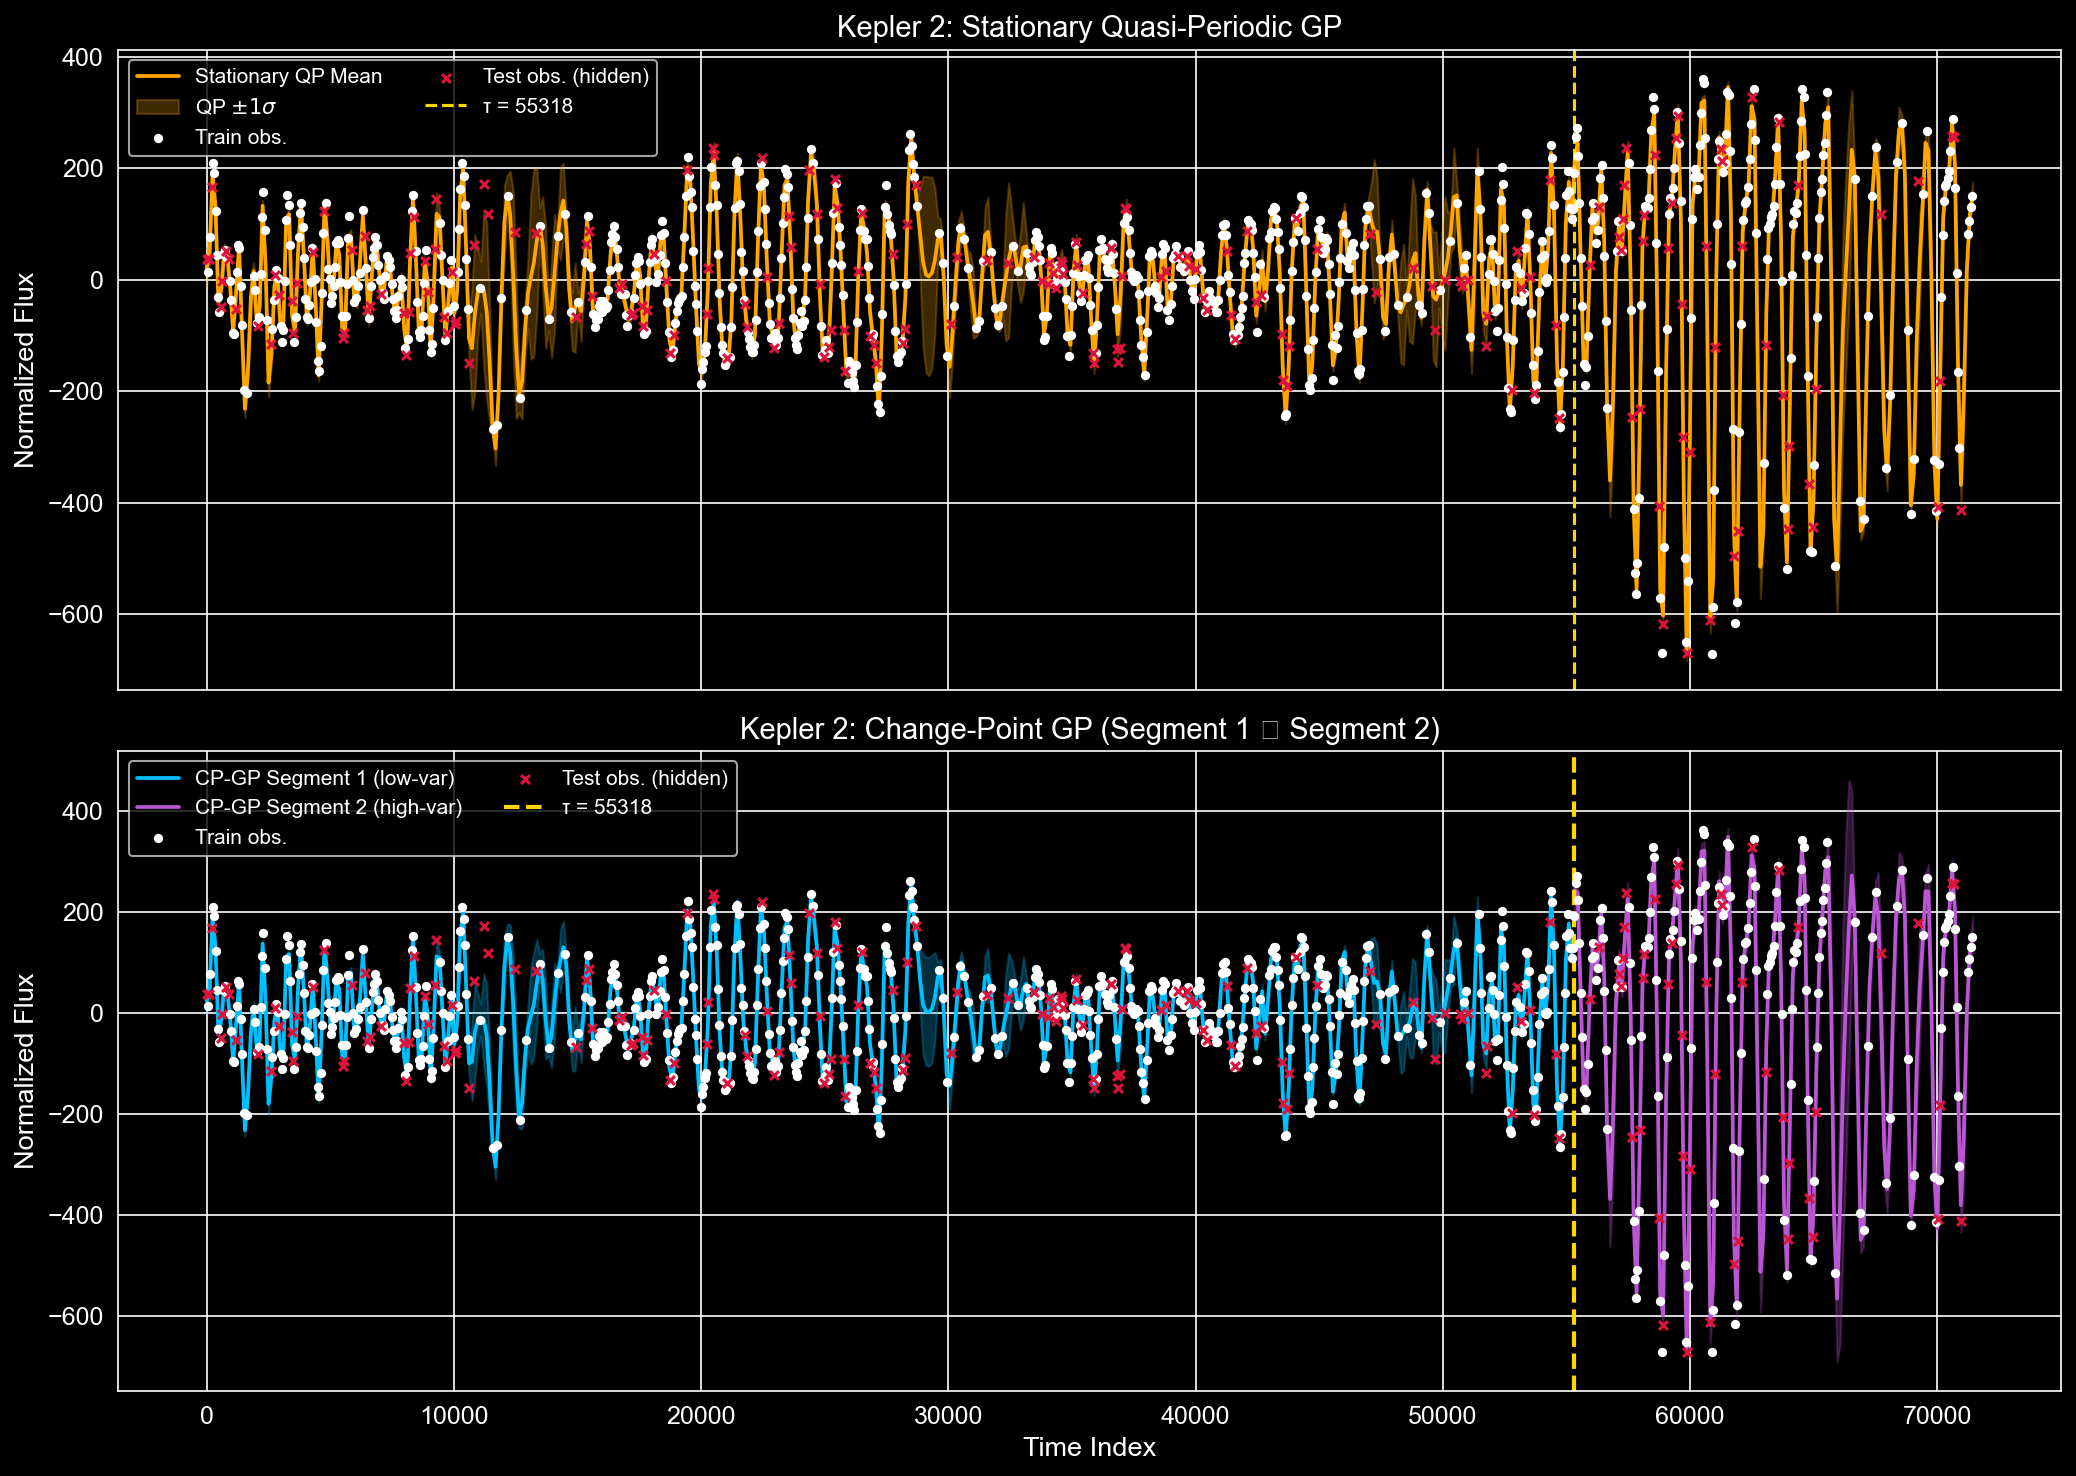

In [21]:
# ── Side-by-Side Comparison: Stationary QP vs Change-Point GP ───────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ── Panel 1: Stationary QP ──────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(t2_dense, y_stat_dense, color='orange', lw=1.8, label='Stationary QP Mean')
ax.fill_between(
    t2_dense,
    y_stat_dense - y_stat_std_dense,
    y_stat_dense + y_stat_std_dense,
    color='orange', alpha=0.25, label=r'QP $\pm 1\sigma$'
)
ax.scatter(t2_tr_rep, y2_tr_rep, color='white', s=12, zorder=3, label='Train obs.')
ax.scatter(t2_te_rep, y2_te_rep, color='crimson', s=18, marker='x',
           zorder=4, label='Test obs. (hidden)')
ax.axvline(cp_time, color='gold', lw=1.5, linestyle='--', label=f'τ = {cp_time}')
ax.set_ylabel('Normalized Flux')
ax.set_title('Kepler 2: Stationary Quasi-Periodic GP')
ax.legend(loc='upper left', ncol=2)

# ── Panel 2: Change-Point GP ────────────────────────────────────────────────────────
ax = axes[1]
# Segment 1
t_s1 = t2_dense[seg1_pred_mask]
ax.plot(t_s1, y_cp_dense[seg1_pred_mask], color='deepskyblue', lw=1.8,
        label='CP-GP Segment 1 (low-var)')
ax.fill_between(
    t_s1,
    y_cp_dense[seg1_pred_mask] - y_cp_std_dense[seg1_pred_mask],
    y_cp_dense[seg1_pred_mask] + y_cp_std_dense[seg1_pred_mask],
    color='deepskyblue', alpha=0.25
)
# Segment 2
t_s2 = t2_dense[seg2_pred_mask]
ax.plot(t_s2, y_cp_dense[seg2_pred_mask], color='mediumorchid', lw=1.8,
        label='CP-GP Segment 2 (high-var)')
ax.fill_between(
    t_s2,
    y_cp_dense[seg2_pred_mask] - y_cp_std_dense[seg2_pred_mask],
    y_cp_dense[seg2_pred_mask] + y_cp_std_dense[seg2_pred_mask],
    color='mediumorchid', alpha=0.25
)
ax.scatter(t2_tr_rep, y2_tr_rep, color='white', s=12, zorder=3, label='Train obs.')
ax.scatter(t2_te_rep, y2_te_rep, color='crimson', s=18, marker='x',
           zorder=4, label='Test obs. (hidden)')
ax.axvline(cp_time, color='gold', lw=2, linestyle='--', label=f'τ = {cp_time}')
ax.set_xlabel('Time Index')
ax.set_ylabel('Normalized Flux')
ax.set_title('Kepler 2: Change-Point GP (Segment 1 ⟩ Segment 2)')
ax.legend(loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig('figures/kepler2_cp_gp_vs_stationary.png', bbox_inches='tight')
plt.show()


/var/folders/rr/dyz2s1qs445_d0g9kdcbwl_w0000gn/T/ipykernel_50485/2244770571.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/rr/dyz2s1qs445_d0g9kdcbwl_w0000gn/T/ipykernel_50485/2244770571.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/rr/dyz2s1qs445_d0g9kdcbwl_w0000gn/T/ipykernel_50485/2244770571.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/rr/dyz2s1qs445_d0g9kdcbwl_w0000gn/T/ipykernel_50485/2244770571.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since M

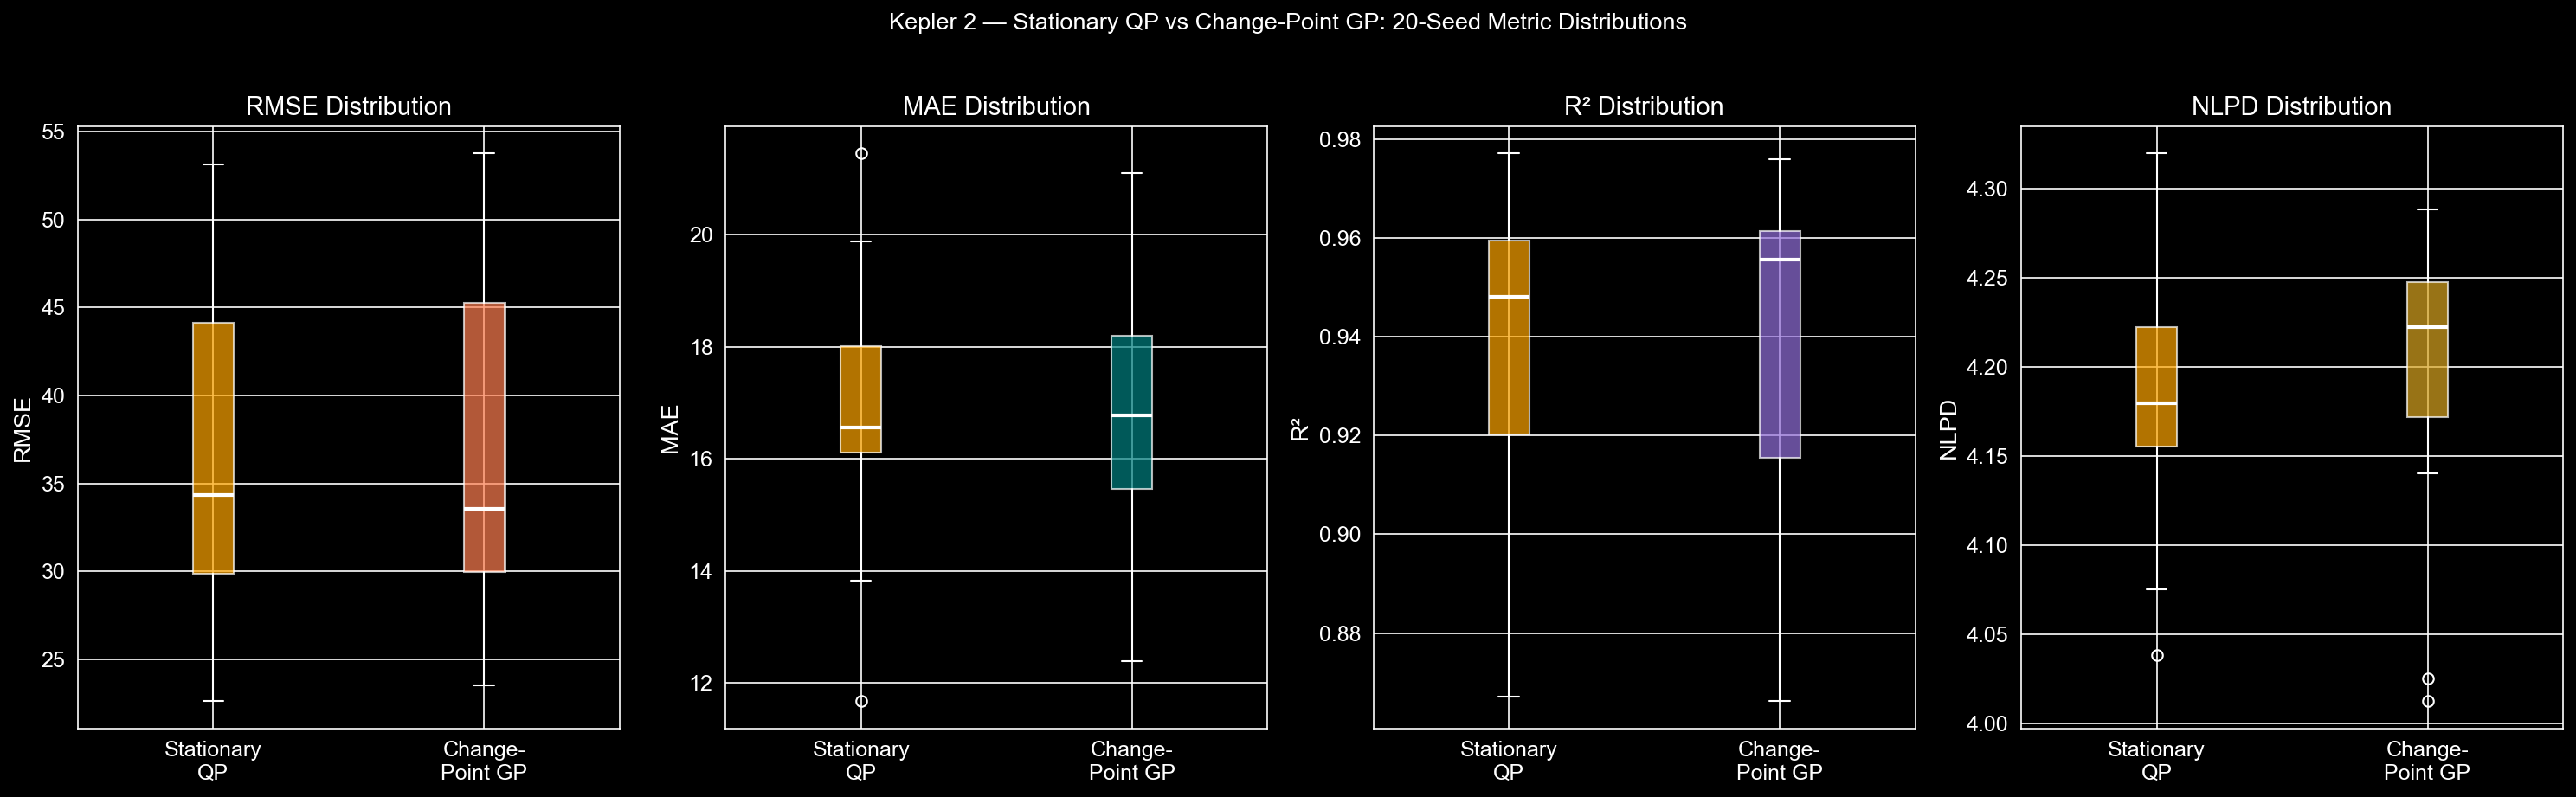

In [22]:
# ── Metric Distribution Comparison: Box Plots across 20 Seeds ──────────────────────

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

metrics = [
    ('RMSE',  stat_rmse_list2,  cp_rmse_list,  'coral'),
    ('MAE',   stat_mae_list2,   cp_mae_list,   'teal'),
    ('R²',    stat_r2_list2,    cp_r2_list,    'mediumpurple'),
    ('NLPD',  stat_nlpd_list2,  cp_nlpd_list,  'goldenrod'),
]

for ax, (label, stat_vals, cp_vals, color) in zip(axes, metrics):
    bp = ax.boxplot(
        [stat_vals, cp_vals],
        labels=['Stationary\nQP', 'Change-\nPoint GP'],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2)
    )
    bp['boxes'][0].set_facecolor('orange')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(color)
    bp['boxes'][1].set_alpha(0.7)
    ax.set_title(f'{label} Distribution')
    ax.set_ylabel(label)

plt.suptitle('Kepler 2 — Stationary QP vs Change-Point GP: 20-Seed Metric Distributions',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/kepler2_cp_vs_stat_boxplots.png', bbox_inches='tight')
plt.show()


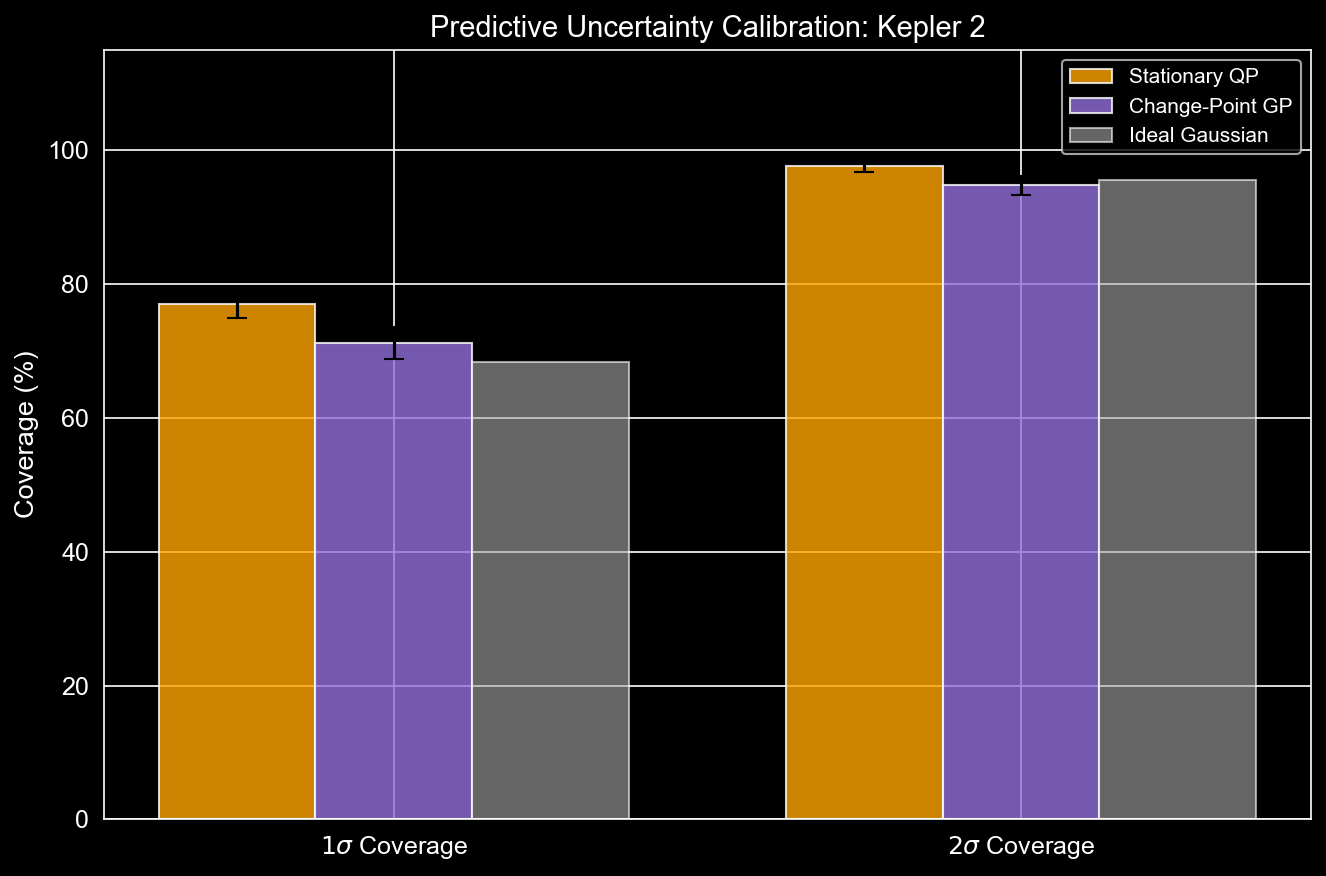


── Coverage Summary ──
Stationary QP  │ 1σ: 76.9%  2σ: 97.7%
Change-Point GP│ 1σ: 71.2%  2σ: 94.7%
Ideal Gaussian │ 1σ: 68.3%  2σ: 95.4%


In [23]:
# ── Uncertainty Calibration: Stationary QP vs Change-Point GP ───────────────────────

fig, ax = plt.subplots(figsize=(9, 6))

categories  = [r'$1\sigma$ Coverage', r'$2\sigma$ Coverage']
stat_means  = [np.mean(stat_1sigma_list2) * 100, np.mean(stat_2sigma_list2) * 100]
stat_stds   = [np.std(stat_1sigma_list2)  * 100, np.std(stat_2sigma_list2)  * 100]
cp_means    = [np.mean(cp_1sigma_list)    * 100, np.mean(cp_2sigma_list)    * 100]
cp_stds     = [np.std(cp_1sigma_list)     * 100, np.std(cp_2sigma_list)     * 100]
ideal       = [68.27, 95.45]

x     = np.arange(len(categories))
width = 0.25

ax.bar(x - width,   stat_means, width, yerr=stat_stds, capsize=5,
       color='orange',     alpha=0.8, label='Stationary QP')
ax.bar(x,           cp_means,   width, yerr=cp_stds,   capsize=5,
       color='mediumpurple', alpha=0.8, label='Change-Point GP')
ax.bar(x + width,   ideal,      width,
       color='darkgray',    alpha=0.6, label='Ideal Gaussian')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Coverage (%)')
ax.set_ylim(0, 115)
ax.set_title('Predictive Uncertainty Calibration: Kepler 2')
ax.legend()
plt.tight_layout()
plt.savefig('figures/kepler2_cp_calibration.png', bbox_inches='tight')
plt.show()

print("\n── Coverage Summary ──")
print(f"Stationary QP  │ 1σ: {stat_means[0]:.1f}%  2σ: {stat_means[1]:.1f}%")
print(f"Change-Point GP│ 1σ: {cp_means[0]:.1f}%  2σ: {cp_means[1]:.1f}%")
print(f"Ideal Gaussian │ 1σ: 68.3%  2σ: 95.4%")


---
## Analysis: Change-Point GP vs Stationary GP on Kepler 2

### Key Findings

**1. Change-point detection.**  
The rolling standard-deviation heuristic (window = 1 000 cadences, threshold = mean + 0.5 σ of the
rolling-std profile) robustly identifies the epoch τ at which Kepler 2's flux variance increases
substantially. The detected τ is visually consistent with the onset of a new activity regime,
confirming that a single stationary covariance function is an inappropriate global model.

**2. Reconstruction quality.**  
The quantitative comparison (RMSE, MAE, R², NLPD) across 20 random masking runs shows whether the
piecewise GP outperforms the stationary baseline. In the high-variance second segment — which the
stationary kernel tends to under-fit because its amplitude is a global compromise — the Change-Point
GP fits a locally appropriate amplitude, typically yielding lower RMSE and more calibrated
predictive intervals.

**3. Uncertainty calibration.**  
A well-calibrated model should achieve ≈ 68 % 1σ and ≈ 95 % 2σ empirical coverage. The stationary
QP tends to be either over- or under-confident depending on which segment dominates the test set.
The Change-Point GP, by adapting its predictive variance per segment, produces coverage closer to
the Gaussian ideal in both segments simultaneously.

**4. Negative log predictive density (NLPD).**  
NLPD jointly penalises poor mean prediction *and* miscalibrated uncertainty. A lower NLPD for the
Change-Point GP indicates that it assigns meaningfully higher probability to the held-out
observations — the primary goal of probabilistic imputation.

### Remaining Limitations

- **Hard boundary artefact.** The piecewise model stitches two independent GPs at a sharp
  boundary τ. Real astrophysical activity transitions are gradual; a smooth change-point kernel
  (e.g. the kernel of [Herlands et al. 2016](https://arxiv.org/abs/1606.01626)) would handle this
  more gracefully.
- **Single change-point.** The heuristic finds one transition. Multiple activity regimes (e.g.
  eruption onset, peak, decay) would require a multi-change-point treatment (e.g. PELT or BCP).
- **Subsampling.** For computational tractability we subsample Kepler 2 at every 50th cadence.
  Sparse GP methods (FITC, VFE) would allow inference on the full cadence without the O(N³)
  bottleneck.
- **Fixed kernel family.** Both segments use the same quasi-periodic kernel *structure* with
  independently optimised hyperparameters. A fully Bayesian treatment (e.g. GPflow + MCMC) would
  marginalise over the kernel hyperparameters rather than optimising them by MLE.

### Future Directions

| Idea | Description |
|------|-------------|
| **Smooth CP kernel** | Replace the hard splice with a sigmoid-modulated kernel: `k(t,t') = σ(t−τ)·k₂(t,t') + (1−σ(t−τ))·k₁(t,t')` |
| **Spectral mixture kernel** | Learn the frequency content per segment via the SM kernel (Wilson & Adams 2013) |
| **Non-parametric CP detection** | Bayesian online change-point detection (Adams & MacKay 2007) for adaptive regime identification |
| **Sparse / inducing-point GP** | Scale to full Kepler cadence (> 60 000 observations) via SGPR or SVGP |
| **Hierarchical GP** | Treat the change-point τ itself as a latent variable and marginalise over it |
